# Objectif du notebook 

Date de création : 11/02/2026

À compléter 


In [1]:
# %matplotlib notebook

import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import scipy.signal as sp 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.spatial.distance import cdist
from datetime import timedelta, datetime
from scipy.stats import linregress
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

rtf_mfp_img_folder = os.path.join(img_folder, "rtf_mfp", "library_active_trailed_event_passive")

In [3]:
sys.path.append(project_root)
from publication.publication_figure import (
    PubFigure,
    LargeFigure,
    color,
    set_subfigures_abc_labels,
)
from propa.rtf.rtf_utils import D_hermitian_angle_fast, D_euclidian


from real_data_analysis.fiberscope_groix.src.fiberscope_groix_manager import (
    # ActiveFiberscopeManager,
    # PassiveFiberscopeManager,
    BandFilter,
)

from real_data_analysis.fiberscope_groix.src.localisation.rtf.rtf_mfp import (
    RTF_MFP_Processor,
)

Text(0.5, 0.01, 'Temps UTC')

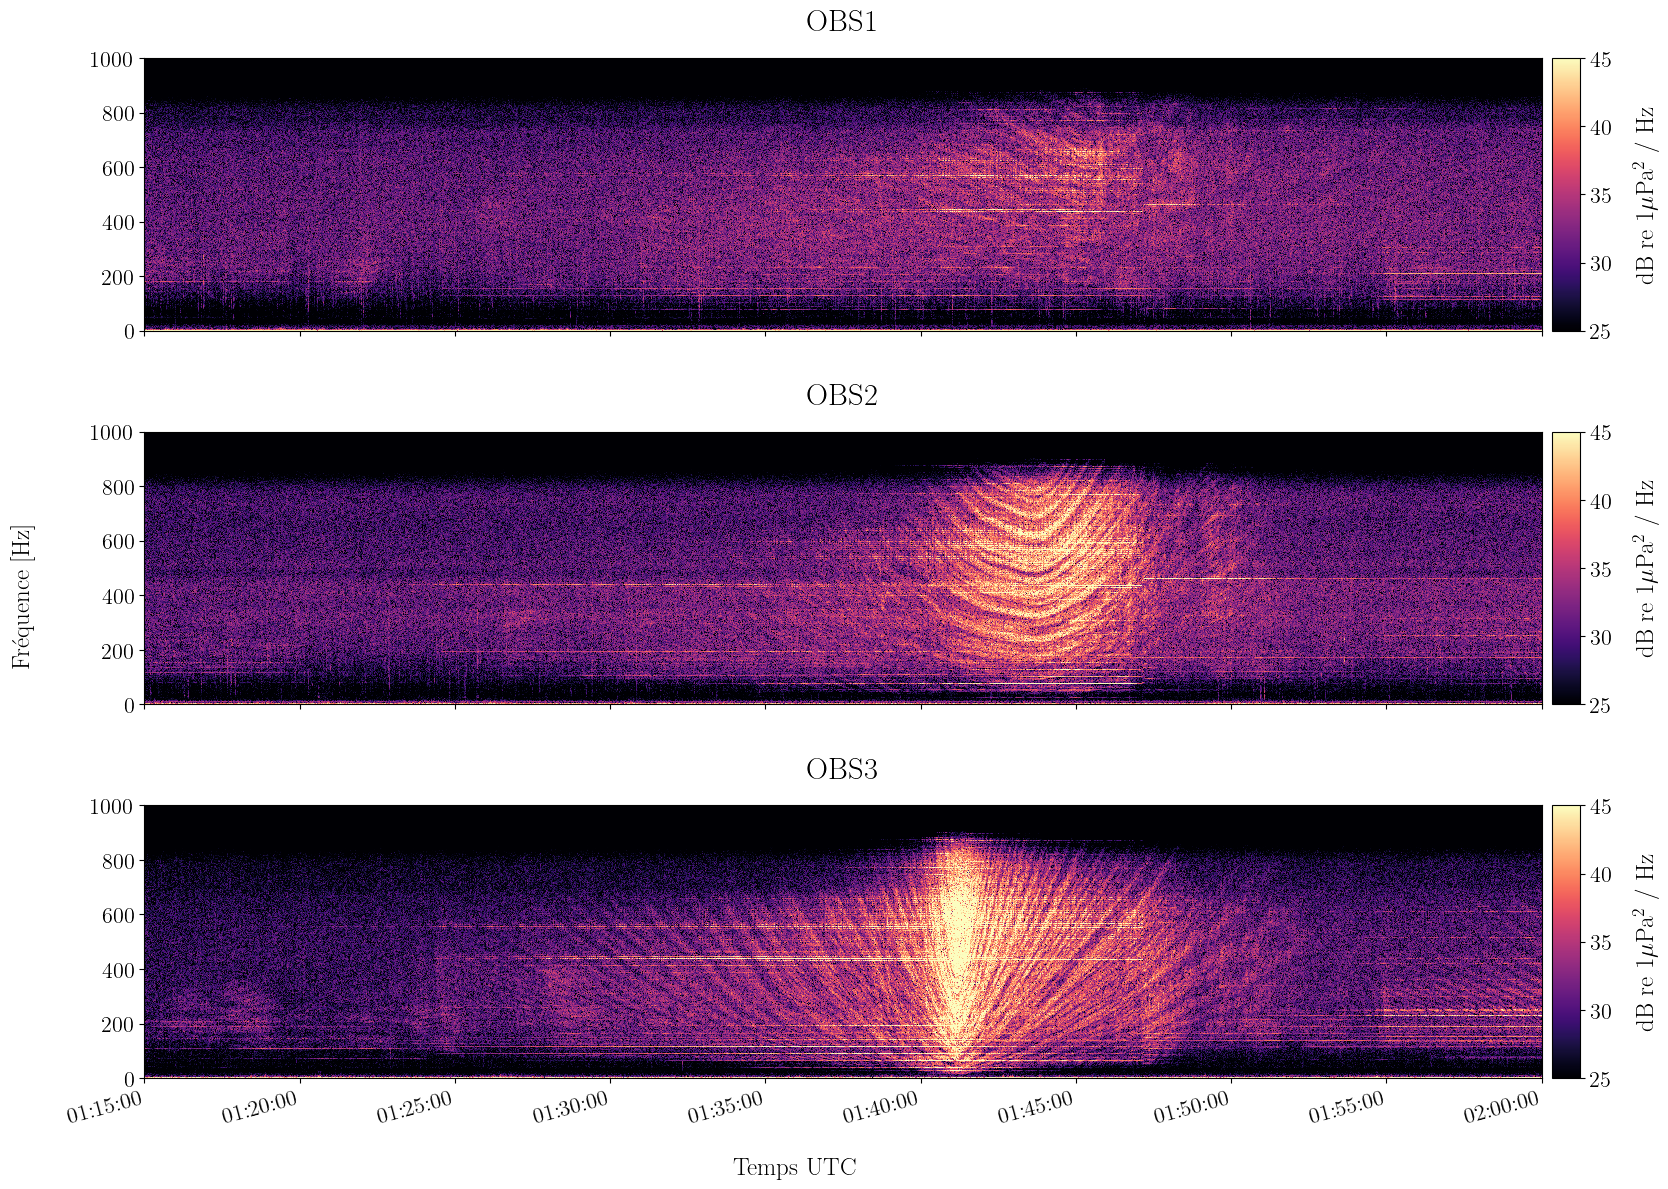

In [4]:
# Load wav data and plot the corresponding sequence
ds_wav = xr.open_dataset(os.path.join(data_folder, "channel_H_wav.nc"))

t_start = datetime(year=2025, month=10, day=14, hour=1, minute=15, second=00)
t_end = datetime(year=2025, month=10, day=14, hour=2, minute=00, second=00)
# Paramètre STFT
nperseg = 2**12
noverlap = 2**11

fig, axs = plt.subplots(3, 1, sharex=True, figsize=(16, 12))
axs = np.atleast_1d(axs)

for i, obs_id in enumerate([1, 2, 3]):

    datetime_fmt = ds_wav.attrs["datetime_format"]

    sig_varname = f"signal_obs{obs_id}"
    time_coordsname = f"time{obs_id}"
    signal = ds_wav[sig_varname]

    # Select a window of the signal
    fs = ds_wav.attrs[f"fs_obs{obs_id}"]

    # Start of recording
    t0 = ds_wav.attrs[f"start_datetime_obs{obs_id}"]
    t0 = datetime.strptime(t0, datetime_fmt)

    # Select window
    t_from_t0_start_s = (t_start - t0).total_seconds()
    n_start = int(t_from_t0_start_s * fs)
    t_from_t0_end_s = (t_end - t0).total_seconds()
    n_end = int(t_from_t0_end_s * fs)

    # Slice signal
    sig_win = signal.isel({time_coordsname: slice(n_start, n_end)})

    # Define datetime borders
    t0_slice = t0 + timedelta(seconds=n_start * 1 / fs)
    t1_slice = t0 + timedelta(seconds=n_end * 1 / fs)

    # Derive stft
    ff, tt, stft = sp.stft(
        sig_win.values,  # .values -> ici on charge les données en mémoire (un tout petit subset seulement)
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        scaling="psd",  # U^2 / Hz
    )
    sxx = 10 * np.log10(np.abs(stft))  # dB re 1uPa**2 / Hz ou dB re 1 (m/s)^2 / Hz
    # Associated datetime vector
    tt_datetime = pd.date_range(
        t0_slice,
        t0_slice + timedelta(seconds=tt[-1]),
        freq=f"{tt[1]-tt[0]}s",
        inclusive="both",
    )

    # Plot
    cmap = "magma"
    # vmin = np.percentile(sxx, 10)
    # vmax = np.percentile(sxx, 99)
    vmin = 25
    vmax = 45

    im = axs[i].pcolormesh(tt_datetime, ff, sxx, cmap=cmap, vmin=vmin, vmax=vmax)

    clabel = r"dB re 1$\mu$Pa$^2$ / Hz"
    divider = make_axes_locatable(axs[i])
    cax = divider.append_axes("right", size="2%", pad=0.10)
    fig.colorbar(im, cax=cax, orientation="vertical", label=clabel)

    # axs[ich].colorbar(im, label=clabel)

    axs[i].set_title(f"OBS{obs_id}")

formatter = mdates.DateFormatter("%H:%M:%S")
axs[-1].xaxis.set_major_formatter(formatter)
formatter = mdates.DateFormatter("%H:%M:%S")
axs[-1].xaxis.set_major_formatter(formatter)
locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
axs[-1].xaxis.set_major_locator(locator)
plt.setp(axs[-1].get_xticklabels(), rotation=15, ha="right")


# nticks = 10
# xmin, xmax = axs[-1].get_xlim()
# axs[-1].set_xticks(np.linspace(xmin, xmax, nticks))
# plt.setp(axs[-1].get_xticklabels(), rotation=25, ha="center")

fig.supylabel("Fréquence [Hz]")
fig.supxlabel("Temps UTC")
# fig.suptitle(f"OBS{obs_id}")

# fpath = os.path.join(root_fig, "spectro_3obs.png")
# plt.savefig(fpath, bbox_inches="tight")

In [5]:
# # Load wav data and plot the corresponding sequence
# ds_wav = xr.open_dataset(os.path.join(data_folder, "channel_H_wav.nc"))

# t_start = datetime(year=2025, month=10, day=14, hour=1, minute=15, second=00)
# t_end = datetime(year=2025, month=10, day=14, hour=2, minute=00, second=00)

# # Paramètre STFT
# nperseg = 2**12
# noverlap = 2**11

# fig, axs = plt.subplots(4, 1, sharex=True, figsize=(16, 12))
# axs = np.atleast_1d(axs)


# for i, obs_id in enumerate([1, 2, 3]):

#     datetime_fmt = ds_wav.attrs["datetime_format"]

#     sig_varname = f"signal_obs{obs_id}"
#     time_coordsname = f"time{obs_id}"
#     signal = ds_wav[sig_varname]

#     # Select a window of the signal
#     fs = ds_wav.attrs[f"fs_obs{obs_id}"]

#     # Start of recording
#     t0 = ds_wav.attrs[f"start_datetime_obs{obs_id}"]
#     t0 = datetime.strptime(t0, datetime_fmt)

#     # Select window
#     t_from_t0_start_s = (t_start - t0).total_seconds()
#     n_start = int(t_from_t0_start_s * fs)
#     t_from_t0_end_s = (t_end - t0).total_seconds()
#     n_end = int(t_from_t0_end_s * fs)

#     # Slice signal
#     sig_win = signal.isel({time_coordsname: slice(n_start, n_end)})

#     # Define datetime borders
#     t0_slice = t0 + timedelta(seconds=n_start * 1 / fs)
#     t1_slice = t0 + timedelta(seconds=n_end * 1 / fs)

#     # Derive stft
#     ff, tt, stft = sp.stft(
#         sig_win.values,  # .values -> ici on charge les données en mémoire (un tout petit subset seulement)
#         fs=fs,
#         window="hann",
#         nperseg=nperseg,
#         noverlap=noverlap,
#         scaling="psd",  # U^2 / Hz
#     )
#     sxx = 10 * np.log10(np.abs(stft))  # dB re 1uPa**2 / Hz ou dB re 1 (m/s)^2 / Hz
#     # Associated datetime vector
#     tt_datetime = pd.date_range(
#         t0_slice,
#         t0_slice + timedelta(seconds=tt[-1]),
#         freq=f"{tt[1]-tt[0]}s",
#         inclusive="both",
#     )

#     # Sum over entire band
#     dff = ff[1] - ff[0]
#     s = np.sum(np.abs(stft), axis=0) * dff

#     # s /= s.max()

#     if i == 0:
#         s_combine = s
#     else:
#         s_combine *= s

#     # Plot
#     axs[i].plot(tt_datetime, s)
#     axs[i].set_title(f"OBS{obs_id}")

# s_combine /= s_combine.max()
# axs[-1].plot(tt_datetime, s_combine)


# formatter = mdates.DateFormatter("%H:%M:%S")
# axs[-1].xaxis.set_major_formatter(formatter)
# formatter = mdates.DateFormatter("%H:%M:%S")
# axs[-1].xaxis.set_major_formatter(formatter)
# locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
# axs[-1].xaxis.set_major_locator(locator)
# plt.setp(axs[-1].get_xticklabels(), rotation=15, ha="right")


# # nticks = 10
# # xmin, xmax = axs[-1].get_xlim()
# # axs[-1].set_xticks(np.linspace(xmin, xmax, nticks))
# # plt.setp(axs[-1].get_xticklabels(), rotation=25, ha="center")

# # fig.supylabel("Fréquence [Hz]")
# fig.supxlabel("Temps UTC")
# # fig.suptitle(f"OBS{obs_id}")

# # fpath = os.path.join(root_fig, "spectro_3obs.png")
# # plt.savefig(fpath, bbox_inches="tight")

In [6]:
# # Load wav data and plot the corresponding sequence
# ds_wav = xr.open_dataset(os.path.join(data_folder, "channel_H_wav.nc"))

# t_start = datetime(year=2025, month=10, day=14, hour=16, minute=30, second=30)
# t_end =  datetime(year=2025, month=10, day=14, hour=17, minute=15, second=30)
# # Paramètre STFT
# nperseg = 2**12
# noverlap = 2**11

# fig, axs = plt.subplots(3, 1, sharex=True, figsize=(16, 12))
# axs = np.atleast_1d(axs)

# for i, obs_id in enumerate([1, 2, 3]):

#     datetime_fmt = ds_wav.attrs["datetime_format"]

#     sig_varname = f"signal_obs{obs_id}"
#     time_coordsname = f"time{obs_id}"
#     signal = ds_wav[sig_varname]

#     # Select a window of the signal
#     fs = ds_wav.attrs[f"fs_obs{obs_id}"]

#     # Start of recording
#     t0 = ds_wav.attrs[f"start_datetime_obs{obs_id}"]
#     t0 = datetime.strptime(t0, datetime_fmt)

#     # Select window
#     t_from_t0_start_s = (t_start - t0).total_seconds()
#     n_start = int(t_from_t0_start_s * fs)
#     t_from_t0_end_s = (t_end - t0).total_seconds()
#     n_end = int(t_from_t0_end_s * fs)

#     # Slice signal
#     sig_win = signal.isel({time_coordsname: slice(n_start, n_end)})

#     # Define datetime borders
#     t0_slice = t0 + timedelta(seconds=n_start * 1 / fs)
#     t1_slice = t0 + timedelta(seconds=n_end * 1 / fs)

#     # Derive stft
#     ff, tt, stft = sp.stft(
#         sig_win.values,  # .values -> ici on charge les données en mémoire (un tout petit subset seulement)
#         fs=fs,
#         window="hann",
#         nperseg=nperseg,
#         noverlap=noverlap,
#         scaling="psd",  # U^2 / Hz
#     )
#     sxx = 10 * np.log10(np.abs(stft))  # dB re 1uPa**2 / Hz ou dB re 1 (m/s)^2 / Hz
#     # Associated datetime vector
#     tt_datetime = pd.date_range(
#         t0_slice,
#         t0_slice + timedelta(seconds=tt[-1]),
#         freq=f"{tt[1]-tt[0]}s",
#         inclusive="both",
#     )

#     # Plot
#     cmap = "magma"
#     # vmin = np.percentile(sxx, 10)
#     # vmax = np.percentile(sxx, 99)
#     vmin = 25
#     vmax = 45

#     im = axs[i].pcolormesh(tt_datetime, ff, sxx, cmap=cmap, vmin=vmin, vmax=vmax)

#     clabel = r"dB re 1$\mu$Pa$^2$ / Hz"
#     divider = make_axes_locatable(axs[i])
#     cax = divider.append_axes("right", size="2%", pad=0.10)
#     fig.colorbar(im, cax=cax, orientation="vertical", label=clabel)

#     # axs[ich].colorbar(im, label=clabel)

#     axs[i].set_title(f"OBS{obs_id}")

# formatter = mdates.DateFormatter("%H:%M:%S")
# axs[-1].xaxis.set_major_formatter(formatter)
# formatter = mdates.DateFormatter("%H:%M:%S")
# axs[-1].xaxis.set_major_formatter(formatter)
# locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
# axs[-1].xaxis.set_major_locator(locator)
# plt.setp(axs[-1].get_xticklabels(), rotation=15, ha="right")


# # nticks = 10
# # xmin, xmax = axs[-1].get_xlim()
# # axs[-1].set_xticks(np.linspace(xmin, xmax, nticks))
# # plt.setp(axs[-1].get_xticklabels(), rotation=25, ha="center")

# fig.supylabel("Fréquence [Hz]")
# fig.supxlabel("Temps UTC")
# # fig.suptitle(f"OBS{obs_id}")

# # fpath = os.path.join(root_fig, "spectro_3obs.png")
# # plt.savefig(fpath, bbox_inches="tight")


In [7]:
# # Load wav data and plot the corresponding sequence
# ds_wav = xr.open_dataset(os.path.join(data_folder, "channel_H_wav.nc"))

# t_start = datetime(year=2025, month=10, day=14, hour=16, minute=30, second=30)
# t_end = datetime(year=2025, month=10, day=14, hour=17, minute=15, second=30)

# # Paramètre STFT
# nperseg = 2**12
# noverlap = 2**11

# fig, axs = plt.subplots(4, 1, sharex=True, figsize=(16, 12))
# axs = np.atleast_1d(axs)


# for i, obs_id in enumerate([1, 2, 3]):

#     datetime_fmt = ds_wav.attrs["datetime_format"]

#     sig_varname = f"signal_obs{obs_id}"
#     time_coordsname = f"time{obs_id}"
#     signal = ds_wav[sig_varname]

#     # Select a window of the signal
#     fs = ds_wav.attrs[f"fs_obs{obs_id}"]

#     # Start of recording
#     t0 = ds_wav.attrs[f"start_datetime_obs{obs_id}"]
#     t0 = datetime.strptime(t0, datetime_fmt)

#     # Select window
#     t_from_t0_start_s = (t_start - t0).total_seconds()
#     n_start = int(t_from_t0_start_s * fs)
#     t_from_t0_end_s = (t_end - t0).total_seconds()
#     n_end = int(t_from_t0_end_s * fs)

#     # Slice signal
#     sig_win = signal.isel({time_coordsname: slice(n_start, n_end)})

#     # Define datetime borders
#     t0_slice = t0 + timedelta(seconds=n_start * 1 / fs)
#     t1_slice = t0 + timedelta(seconds=n_end * 1 / fs)

#     # Derive stft
#     ff, tt, stft = sp.stft(
#         sig_win.values,  # .values -> ici on charge les données en mémoire (un tout petit subset seulement)
#         fs=fs,
#         window="hann",
#         nperseg=nperseg,
#         noverlap=noverlap,
#         scaling="psd",  # U^2 / Hz
#     )
#     sxx = 10 * np.log10(np.abs(stft))  # dB re 1uPa**2 / Hz ou dB re 1 (m/s)^2 / Hz
#     # Associated datetime vector
#     tt_datetime = pd.date_range(
#         t0_slice,
#         t0_slice + timedelta(seconds=tt[-1]),
#         freq=f"{tt[1]-tt[0]}s",
#         inclusive="both",
#     )

#     # Sum over entire band
#     dff = ff[1] - ff[0]
#     s = np.sum(np.abs(stft), axis=0) * dff

#     s /= s.max()

#     if i == 0:
#         s_combine = s
#     else:
#         s_combine *= s

#     # Plot
#     axs[i].plot(tt_datetime, s)
#     axs[i].set_title(f"OBS{obs_id}")

# s_combine /= s_combine.max()
# axs[-1].plot(tt_datetime, s_combine)

# s_comb_th = np.percentile(s_combine, 65)
# axs[-1].axhline(s_comb_th, linestyle="--", color="k")
# axs[-1].set_yscale("log")

# # Before max
# idx_max = np.argmax(s_combine)
# s_before_max = s_combine[0:idx_max]
# idx_last_under_th = np.where(s_before_max <= s_comb_th)[0].max()

# # After max
# s_after_max = s_combine[idx_max:]
# idx_first_under_th = np.where(s_after_max <= s_comb_th)[0].min() + idx_max

# tt_dt_start_sig = tt_datetime[idx_last_under_th]
# tt_dt_end_sig = tt_datetime[idx_first_under_th]
# axs[-1].axvline(tt_dt_start_sig, linestyle="--", color="r")
# axs[-1].axvline(tt_dt_end_sig, linestyle="--", color="r")

# formatter = mdates.DateFormatter("%H:%M:%S")
# axs[-1].xaxis.set_major_formatter(formatter)
# formatter = mdates.DateFormatter("%H:%M:%S")
# axs[-1].xaxis.set_major_formatter(formatter)
# locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
# axs[-1].xaxis.set_major_locator(locator)
# plt.setp(axs[-1].get_xticklabels(), rotation=15, ha="right")


# # nticks = 10
# # xmin, xmax = axs[-1].get_xlim()
# # axs[-1].set_xticks(np.linspace(xmin, xmax, nticks))
# # plt.setp(axs[-1].get_xticklabels(), rotation=25, ha="center")

# # fig.supylabel("Fréquence [Hz]")
# fig.supxlabel("Temps UTC")
# # fig.suptitle(f"OBS{obs_id}")

# # fpath = os.path.join(root_fig, "spectro_3obs.png")
# # plt.savefig(fpath, bbox_inches="tight")

In [8]:
# # Load wav data and plot the corresponding sequence
# ds_wav = xr.open_dataset(os.path.join(data_folder, "channel_H_wav.nc"))

# t_start = datetime(year=2025, month=10, day=14, hour=16, minute=30, second=30)
# t_end = datetime(year=2025, month=10, day=14, hour=17, minute=15, second=30)
# # Paramètre STFT
# nperseg = 2**12
# noverlap = 2**11

# fig, axs = plt.subplots(3, 1, sharex=True, figsize=(16, 12))
# axs = np.atleast_1d(axs)

# for i, obs_id in enumerate([1, 2, 3]):

#     datetime_fmt = ds_wav.attrs["datetime_format"]

#     sig_varname = f"signal_obs{obs_id}"
#     time_coordsname = f"time{obs_id}"
#     signal = ds_wav[sig_varname]

#     # Select a window of the signal
#     fs = ds_wav.attrs[f"fs_obs{obs_id}"]

#     # Start of recording
#     t0 = ds_wav.attrs[f"start_datetime_obs{obs_id}"]
#     t0 = datetime.strptime(t0, datetime_fmt)

#     # Select window
#     t_from_t0_start_s = (t_start - t0).total_seconds()
#     n_start = int(t_from_t0_start_s * fs)
#     t_from_t0_end_s = (t_end - t0).total_seconds()
#     n_end = int(t_from_t0_end_s * fs)

#     # Slice signal
#     sig_win = signal.isel({time_coordsname: slice(n_start, n_end)})

#     # Define datetime borders
#     t0_slice = t0 + timedelta(seconds=n_start * 1 / fs)
#     t1_slice = t0 + timedelta(seconds=n_end * 1 / fs)

#     # Derive stft
#     ff, tt, stft = sp.stft(
#         sig_win.values,  # .values -> ici on charge les données en mémoire (un tout petit subset seulement)
#         fs=fs,
#         window="hann",
#         nperseg=nperseg,
#         noverlap=noverlap,
#         scaling="psd",  # U^2 / Hz
#     )
#     sxx = 10 * np.log10(np.abs(stft))  # dB re 1uPa**2 / Hz ou dB re 1 (m/s)^2 / Hz
#     # Associated datetime vector
#     tt_datetime = pd.date_range(
#         t0_slice,
#         t0_slice + timedelta(seconds=tt[-1]),
#         freq=f"{tt[1]-tt[0]}s",
#         inclusive="both",
#     )

#     # Plot
#     cmap = "magma"
#     # vmin = np.percentile(sxx, 10)
#     # vmax = np.percentile(sxx, 99)
#     vmin = 25
#     vmax = 45

#     im = axs[i].pcolormesh(tt_datetime, ff, sxx, cmap=cmap, vmin=vmin, vmax=vmax)

#     clabel = r"dB re 1$\mu$Pa$^2$ / Hz"
#     divider = make_axes_locatable(axs[i])
#     cax = divider.append_axes("right", size="2%", pad=0.10)
#     fig.colorbar(im, cax=cax, orientation="vertical", label=clabel)

#     tt_noise_win_dur = timedelta(seconds=5*60)
#     tt_dt_start_noise_win_1 = tt_dt_start_sig - tt_noise_win_dur
#     tt_end_noise_win_1 = tt_dt_start_sig
#     axs[i].axvline(tt_dt_start_noise_win_1, linestyle="--", color="r")
#     axs[i].axvline(tt_end_noise_win_1, linestyle="--", color="r")
#     tt_dt_start_noise_win_2 = tt_dt_end_sig
#     tt_end_noise_win_2 = tt_dt_end_sig + tt_noise_win_dur
#     axs[i].axvline(tt_dt_start_noise_win_2, linestyle="--", color="g")
#     axs[i].axvline(tt_end_noise_win_2, linestyle="--", color="g")

#     axs[i].set_title(f"OBS{obs_id}")

# formatter = mdates.DateFormatter("%H:%M:%S")
# axs[-1].xaxis.set_major_formatter(formatter)
# formatter = mdates.DateFormatter("%H:%M:%S")
# axs[-1].xaxis.set_major_formatter(formatter)
# locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
# axs[-1].xaxis.set_major_locator(locator)
# plt.setp(axs[-1].get_xticklabels(), rotation=15, ha="right")


# fig.supylabel("Fréquence [Hz]")
# fig.supxlabel("Temps UTC")

In [9]:
def get_noise_csdm(start_dt, end_dt, rtf_mfp_processor, sig_percentile: int = 65):

    tt_noise_win_dur = timedelta(seconds=5*60)

    sxx_arr = []
    s_energy_arr = []

    for i, obs_id in enumerate([1, 2, 3]):

        datetime_fmt = ds_wav.attrs["datetime_format"]

        sig_varname = f"signal_obs{obs_id}"
        time_coordsname = f"time{obs_id}"
        signal = ds_wav[sig_varname]

        # Select a window of the signal
        fs = ds_wav.attrs[f"fs_obs{obs_id}"]

        # Start of recording
        t0 = ds_wav.attrs[f"start_datetime_obs{obs_id}"]
        t0 = datetime.strptime(t0, datetime_fmt)

        # Select window
        t_from_t0_start_s = (start_dt - t0).total_seconds()
        n_start = int(t_from_t0_start_s * fs)
        t_from_t0_end_s = (end_dt - t0).total_seconds()
        n_end = int(t_from_t0_end_s * fs)

        # Slice signal
        sig_win = signal.isel({time_coordsname: slice(n_start, n_end)})

        # Define datetime borders
        t0_slice = t0 + timedelta(seconds=n_start * 1 / fs)
        t1_slice = t0 + timedelta(seconds=n_end * 1 / fs)

        # Derive stft
        ff, tt, stft = sp.stft(
            sig_win.values,  # .values -> ici on charge les données en mémoire (un tout petit subset seulement)
            fs=fs,
            window="hann",
            nperseg=nperseg,
            noverlap=noverlap,
            scaling="psd",  # U^2 / Hz
        )
        sxx = 10 * np.log10(np.abs(stft))  # dB re 1uPa**2 / Hz ou dB re 1 (m/s)^2 / Hz

        sxx_arr.append(sxx)

        # Associated datetime vector
        tt_datetime = pd.date_range(
            t0_slice,
            t0_slice + timedelta(seconds=tt[-1]),
            freq=f"{tt[1]-tt[0]}s",
            inclusive="both",
        )
        # Sum over entire band
        dff = ff[1] - ff[0]
        s = np.sum(np.abs(stft), axis=0) * dff

        s /= s.max()

        s_energy_arr.append(s)

    s_energy_arr = np.array(s_energy_arr)
    sxx_arr = np.array(sxx_arr)

    s_combine = np.prod(s_energy_arr, axis=0)

    s_comb_th = np.percentile(s_combine, sig_percentile)

    # Before max
    idx_max = np.argmax(s_combine)
    s_before_max = s_combine[0:idx_max]
    idx_last_under_th = np.where(s_before_max <= s_comb_th)[0].max()

    # After max
    s_after_max = s_combine[idx_max:]
    idx_first_under_th = np.where(s_after_max <= s_comb_th)[0].min() + idx_max

    tt_dt_start_sig = tt_datetime[idx_last_under_th]
    tt_dt_end_sig = tt_datetime[idx_first_under_th]
    tt_dt_start_noise_win_1 = tt_dt_start_sig - tt_noise_win_dur
    tt_end_noise_win_1 = tt_dt_start_sig
    tt_dt_start_noise_win_2 = tt_dt_end_sig
    tt_end_noise_win_2 = tt_dt_end_sig + tt_noise_win_dur

    fig, axs = plt.subplots(7, 1, sharex=True, figsize=(16, 12))
    axs = np.atleast_1d(axs)

    i_ax = 0 
    for i, obs_id in enumerate([1, 2, 3]):

        axs[i_ax].set_title(f"OBS{obs_id}")
        # axs[i_ax + 1].set_title(f"OBS{obs_id}")

        # Plot spectrogram
        cmap = "magma"
        # vmin = np.percentile(sxx, 10)
        # vmax = np.percentile(sxx, 99)
        vmin = 25
        vmax = 45

        im = axs[i_ax].pcolormesh(
            tt_datetime, ff, sxx_arr[i, ...], cmap=cmap, vmin=vmin, vmax=vmax
        )

        clabel = r"dB re 1$\mu$Pa$^2$ / Hz"
        divider = make_axes_locatable(axs[i_ax])
        cax = divider.append_axes("right", size="2%", pad=0.10)
        fig.colorbar(im, cax=cax, orientation="vertical", label=clabel)

        # Plot energy
        axs[i_ax + 1].plot(tt_datetime, s_energy_arr[i])

        i_ax += 2

    formatter = mdates.DateFormatter("%H:%M:%S")
    axs[-1].xaxis.set_major_formatter(formatter)
    formatter = mdates.DateFormatter("%H:%M:%S")
    axs[-1].xaxis.set_major_formatter(formatter)
    locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
    axs[-1].xaxis.set_major_locator(locator)
    plt.setp(axs[-1].get_xticklabels(), rotation=15, ha="right")

    # Plot combine 
    axs[-1].plot(tt_datetime, s_combine)

    # Plot time limts of noise section
    for i in range(axs.size):
        axs[i].axvline(tt_dt_start_noise_win_1, linestyle="--", color="r")
        axs[i].axvline(tt_end_noise_win_1, linestyle="--", color="r")
        axs[i].axvline(tt_dt_start_noise_win_2, linestyle="--", color="g")
        axs[i].axvline(tt_end_noise_win_2, linestyle="--", color="g")

    fig.supylabel("Fréquence [Hz]")
    fig.supxlabel("Temps UTC")

    # Derive csdm
    f, Rv_before, Rv_after = noise_csdm(
        rtf_mfp_processor=rtf_mfp_processor,
        tt_dt_start_noise_win_1=tt_dt_start_noise_win_1,
        tt_end_noise_win_1=tt_end_noise_win_1,
        tt_dt_start_noise_win_2=tt_dt_start_noise_win_2,
        tt_end_noise_win_2=tt_end_noise_win_2,
    )

    return f, Rv_before, Rv_after

def noise_csdm(
    rtf_mfp_processor,
    tt_dt_start_noise_win_1,
    tt_end_noise_win_1,
    tt_dt_start_noise_win_2,
    tt_end_noise_win_2,
):
    v_before_sig = []
    v_after_sig = []

    for i, obs_id in enumerate([1, 2, 3]):

        datetime_fmt = ds_wav.attrs["datetime_format"]

        sig_varname = f"signal_obs{obs_id}"
        time_coordsname = f"time{obs_id}"
        signal = ds_wav[sig_varname]

        # Select a window of the signal
        fs = ds_wav.attrs[f"fs_obs{obs_id}"]

        # Start of recording
        t0 = ds_wav.attrs[f"start_datetime_obs{obs_id}"]
        t0 = datetime.strptime(t0, datetime_fmt)

        # Select window before signal
        t_from_t0_start_s = (tt_dt_start_noise_win_1 - t0).total_seconds()
        n_start = int(t_from_t0_start_s * fs)
        t_from_t0_end_s = (tt_end_noise_win_1 - t0).total_seconds()
        n_end = int(t_from_t0_end_s * fs)

        # Slice signal
        signal_before = signal.isel({time_coordsname: slice(n_start, n_end)})

        v_before_sig.append(signal_before.values)

        # Select window after signal
        t_from_t0_start_s = (tt_dt_start_noise_win_2 - t0).total_seconds()
        n_start = int(t_from_t0_start_s * fs)
        t_from_t0_end_s = (tt_end_noise_win_2 - t0).total_seconds()
        n_end = int(t_from_t0_end_s * fs)

        # Slice signal
        signal_after = signal.isel({time_coordsname: slice(n_start, n_end)})

        v_after_sig.append(signal_after.values)

    fs = ds_wav.fs_obs1
    v_before_sig = np.array(v_before_sig)
    v_after_sig = np.array(v_after_sig)

    v = v_before_sig.T

    f, Rv_before = rtf_mfp_processor.fsm_passive.cm.get_signal_csdm(
        y=v,
        fs=fs,
        add_identity=False,
        mask_tt=None,
        mask_stft=None,
    )

    v = v_after_sig.T

    f, Rv_after = rtf_mfp_processor.fsm_passive.cm.get_signal_csdm(
        y=v,
        fs=fs,
        add_identity=False,
        mask_tt=None,
        mask_stft=None,
    )

    return f, Rv_before, Rv_after

In [10]:
root_data = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data"
root_img = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\img\rtf_mfp"
ref_rcv_id = 2
rtf_estimator = "cs-evd"

tau_ir_hat = 0.2  # estimated impulse response duration from sequence 144
tau_ir_hat *= 2  # To ensure we include the entire response


fsm_active_kwargs = {
    "bandfilter": BandFilter(order=4, lowcut=100, highcut=900),
    "tau_ir": tau_ir_hat,
    "process_pulse_one_by_one": True,
    "estimate_ir_duration": False,
}
fsm_passive_kwargs = {
    "analysis_segment_duration": 5,
    "analysis_segment_alpha_overlap": 0,
}

rtf_mfp_processor = RTF_MFP_Processor(
    root_data=root_data,
    root_img=root_img,
    reference_receiver_id=ref_rcv_id,
    rtf_estimator=rtf_estimator,
    fsm_active_kwargs=fsm_active_kwargs,
    fsm_passive_kwargs=fsm_passive_kwargs,
    mode="overwrite",
    plot_replicas_features=False,
    verbose=True,
)

In [11]:
rtf_mfp_processor.fsm_passive.cm.nperseg

4096

In [12]:
# Dummy run to set cov_manager and feature_manager
# rtf_mfp_processor.plot_replicas_features = False 
active_replicas_args = {
    "replica_sequence_ids": [],
    "replica_pulse_slice": [],
    "load_precomputed_feature": True,
}

passive_replicas_args = {
    "start_datetimes": [
        datetime(year=2025, month=10, day=14, hour=1, minute=42, second=00),  # OK
    ],
    "end_datetimes": [
        datetime(year=2025, month=10, day=14, hour=1, minute=42, second=30),  # OK
    ],
    "load_precomputed_feature": False,
}


rtf_mfp_processor.compute_library(
    active_feature_args=active_replicas_args,
    passive_feature_args=passive_replicas_args,
    id=0,
    Rv_global=None,
)
# rtf_mfp_processor.plot_replicas_features = True


Deriving features for active source...

Deriving replicas for passive source...

RTF processing of passive recording
RTF feature estimation...
Progress: ████████████████████████████████████████████████████████████████████████████████████████████████████ 100%Using first vessel in list (default behavior) : mmsi=227315990
A library dataset with ID 0 already exists in C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\library. This library dataset will be overwritten.
Dataset (library) saved at C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\library\library_0.nc.


In [13]:
rtf_mfp_processor.fsm_passive.cm.nperseg

4096

In [14]:
# # Library #
# t_start =  datetime(year=2025, month=10, day=14, hour=1, minute=15, second=00)
# t_end = datetime(year=2025, month=10, day=14, hour=2, minute=0, second=00)
# f, Rv_before, Rv_after = get_noise_csdm(
#     start_dt=t_start,
#     end_dt=t_end,
#     rtf_mfp_processor=rtf_mfp_processor,
#     sig_percentile=50,
# )
# Rv_library = (Rv_before + Rv_after) / 2 

# # Event
# t_start = datetime(year=2025, month=10, day=14, hour=16, minute=15, second=30)
# t_end = datetime(year=2025, month=10, day=14, hour=17, minute=15, second=30)
# f, Rv_before, Rv_after = get_noise_csdm(
#     start_dt=t_start,
#     end_dt=t_end,
#     rtf_mfp_processor=rtf_mfp_processor,
#     sig_percentile=60,
# )
# Rv_event = (Rv_before + Rv_after) / 2

In [15]:
# plt.figure()
# im = plt.pcolormesh(np.mean(np.abs(Rv_library), axis=0))
# plt.colorbar(im)

# plt.figure()
# im = plt.pcolormesh(np.mean(np.abs(Rv_event), axis=0))
# plt.colorbar(im)

In [16]:
# f_sel = 400
# idx_f_sel = np.argmin(np.abs(f-f_sel))

# plt.figure()
# im = plt.pcolormesh(np.abs(Rv_library)[idx_f_sel, ...])
# plt.colorbar(im)

# plt.figure()
# im = plt.pcolormesh(np.abs(Rv_event)[idx_f_sel, ...])
# plt.colorbar(im)


Deriving features for active source...

Deriving replicas for passive source...
Precomputed replica for passive segment 2025-10-14 01:40:00 - 2025-10-14 01:50:00 found at C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\sequences\passive\sequence_passive_2025-10-14_01-40-00_to_2025-10-14_01-50-00_rtf.nc. This segment will be loaded instead of being computed.
Using first vessel in list (default behavior) : mmsi=227315990
A library dataset with ID 5 already exists in C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\library. This library dataset will be overwritten.
Dataset (library) saved at C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\library\library_5.nc.

Deriving features for active source...

Provided pulse slices dont match number of sequences, no slice applied.

Deriving replicas for passive source...
Precomputed replica for passive segment 2025-10-14 16:44:00 - 2

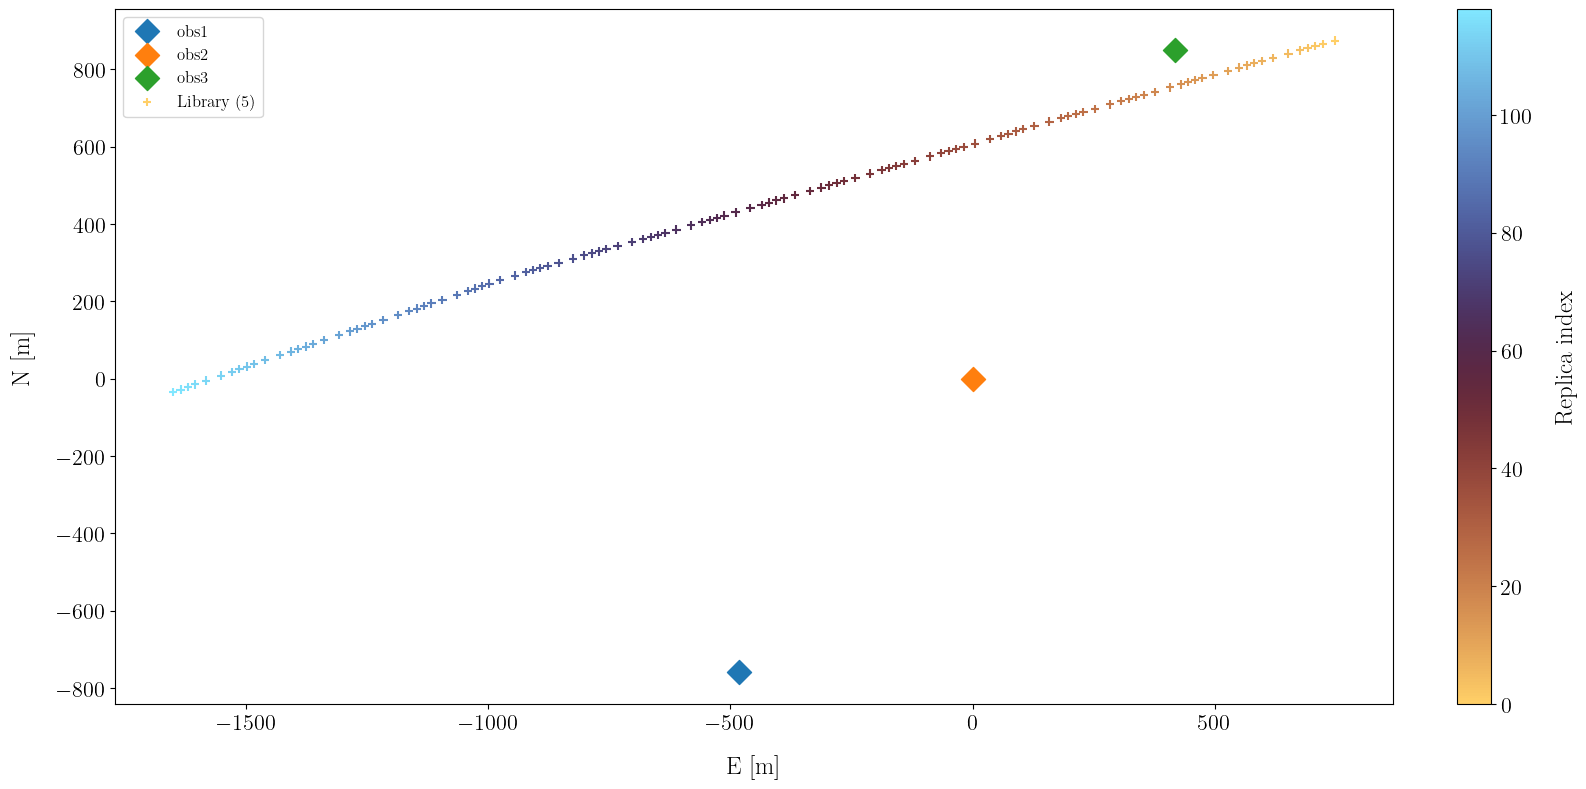

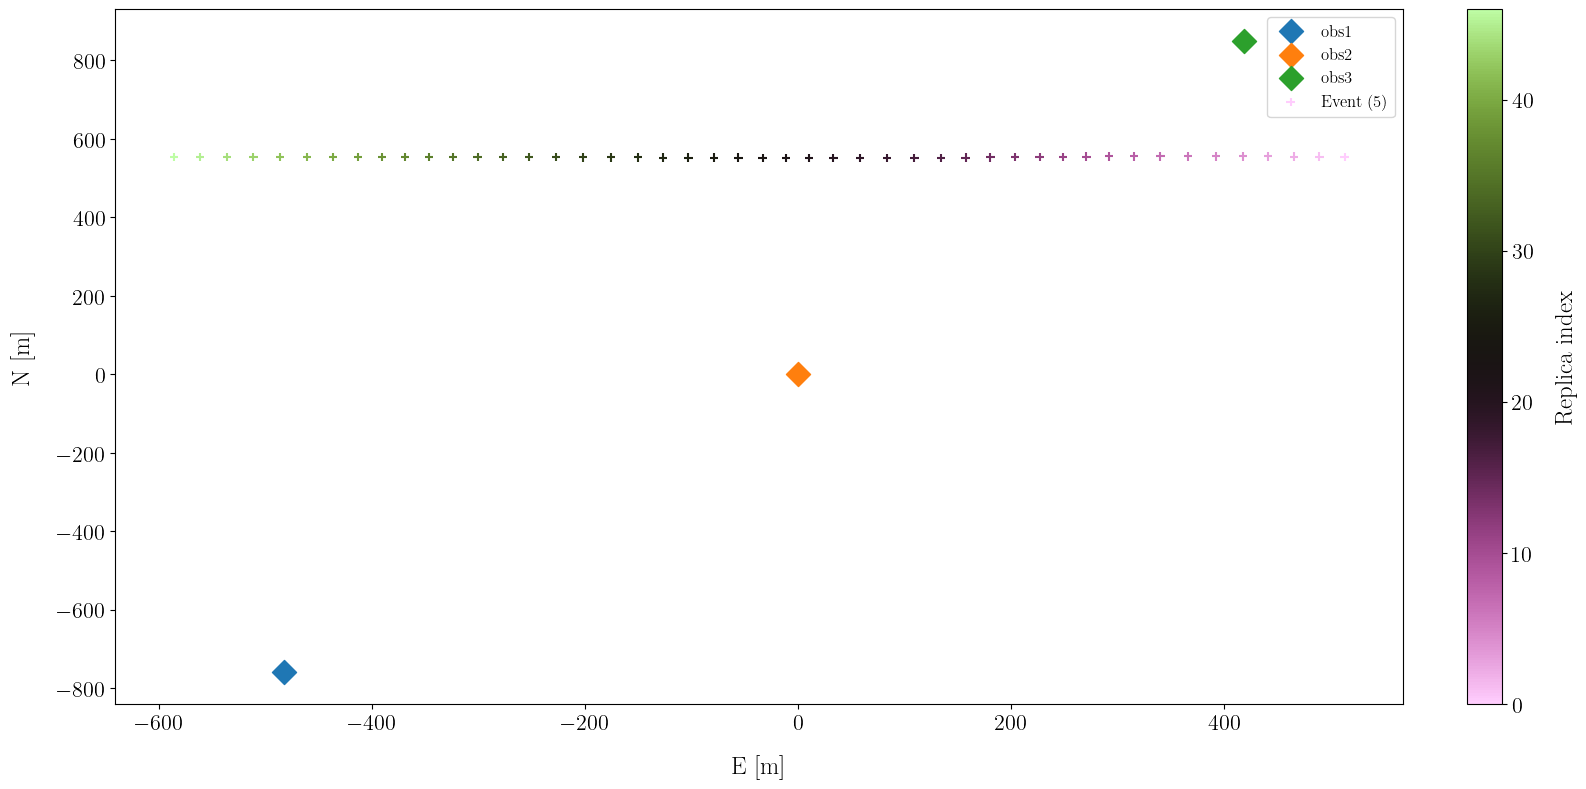

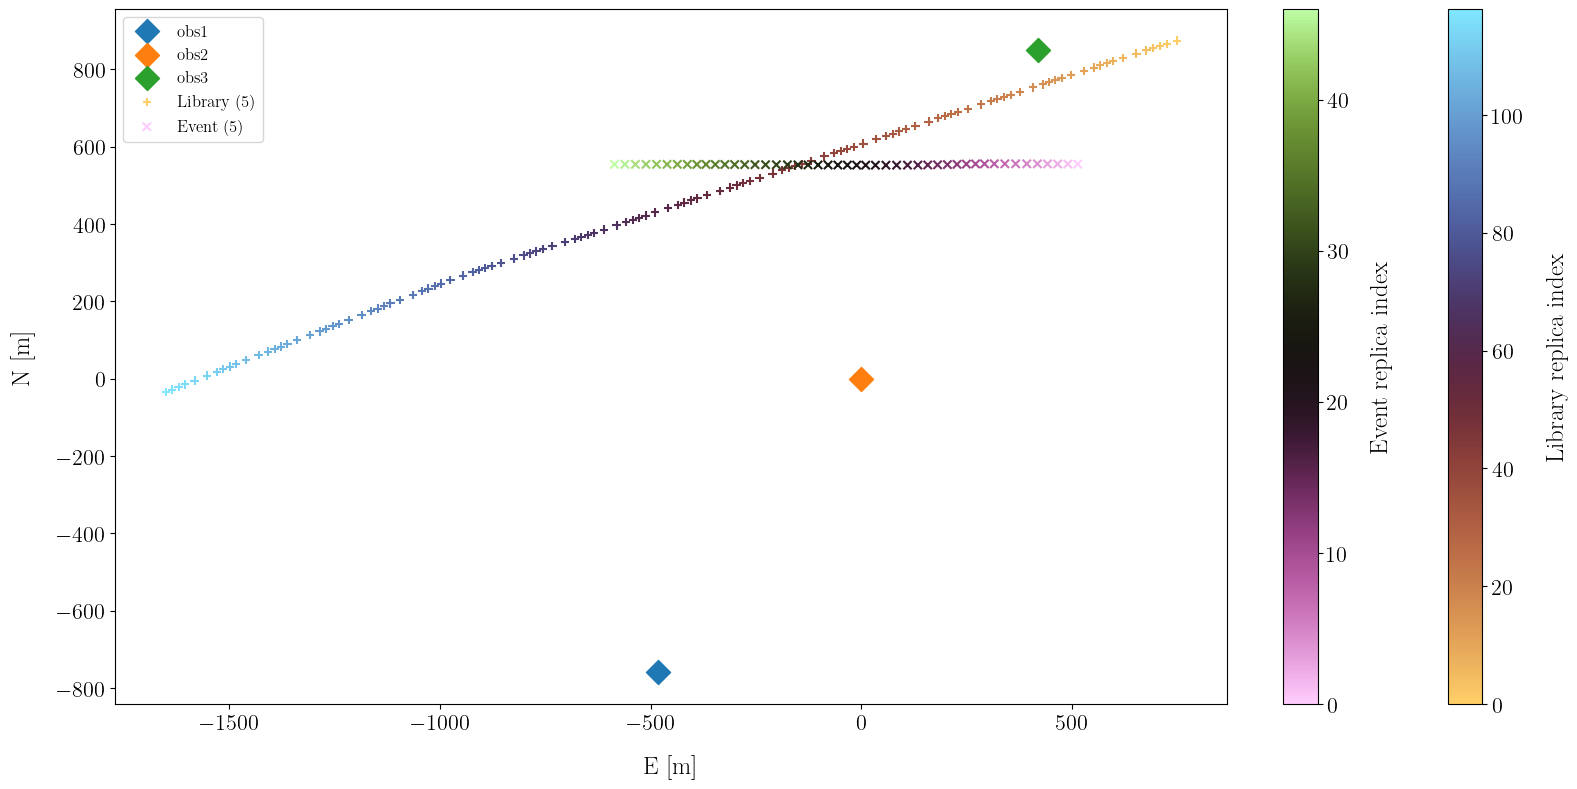

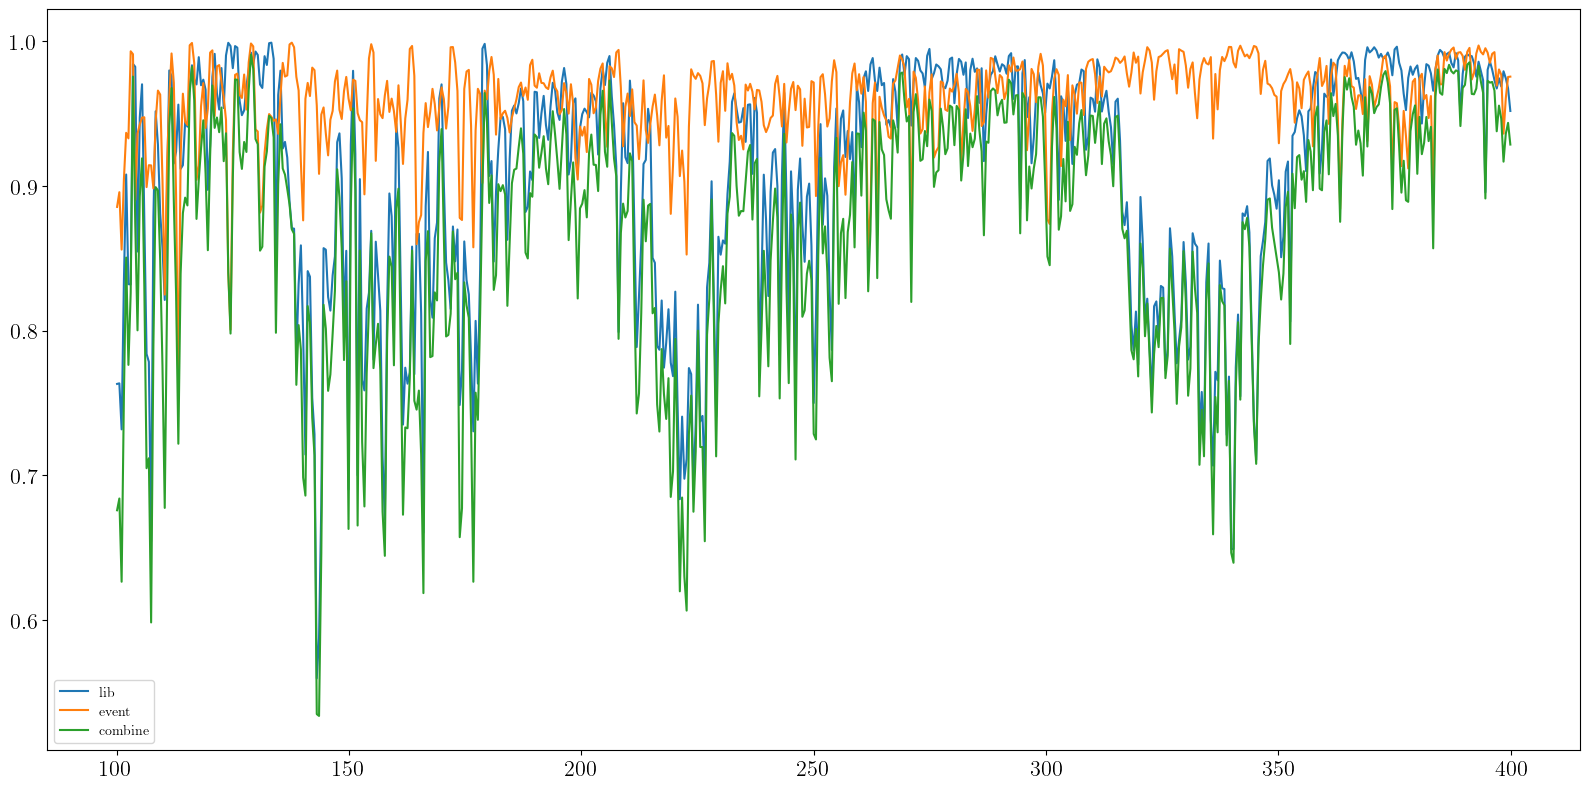

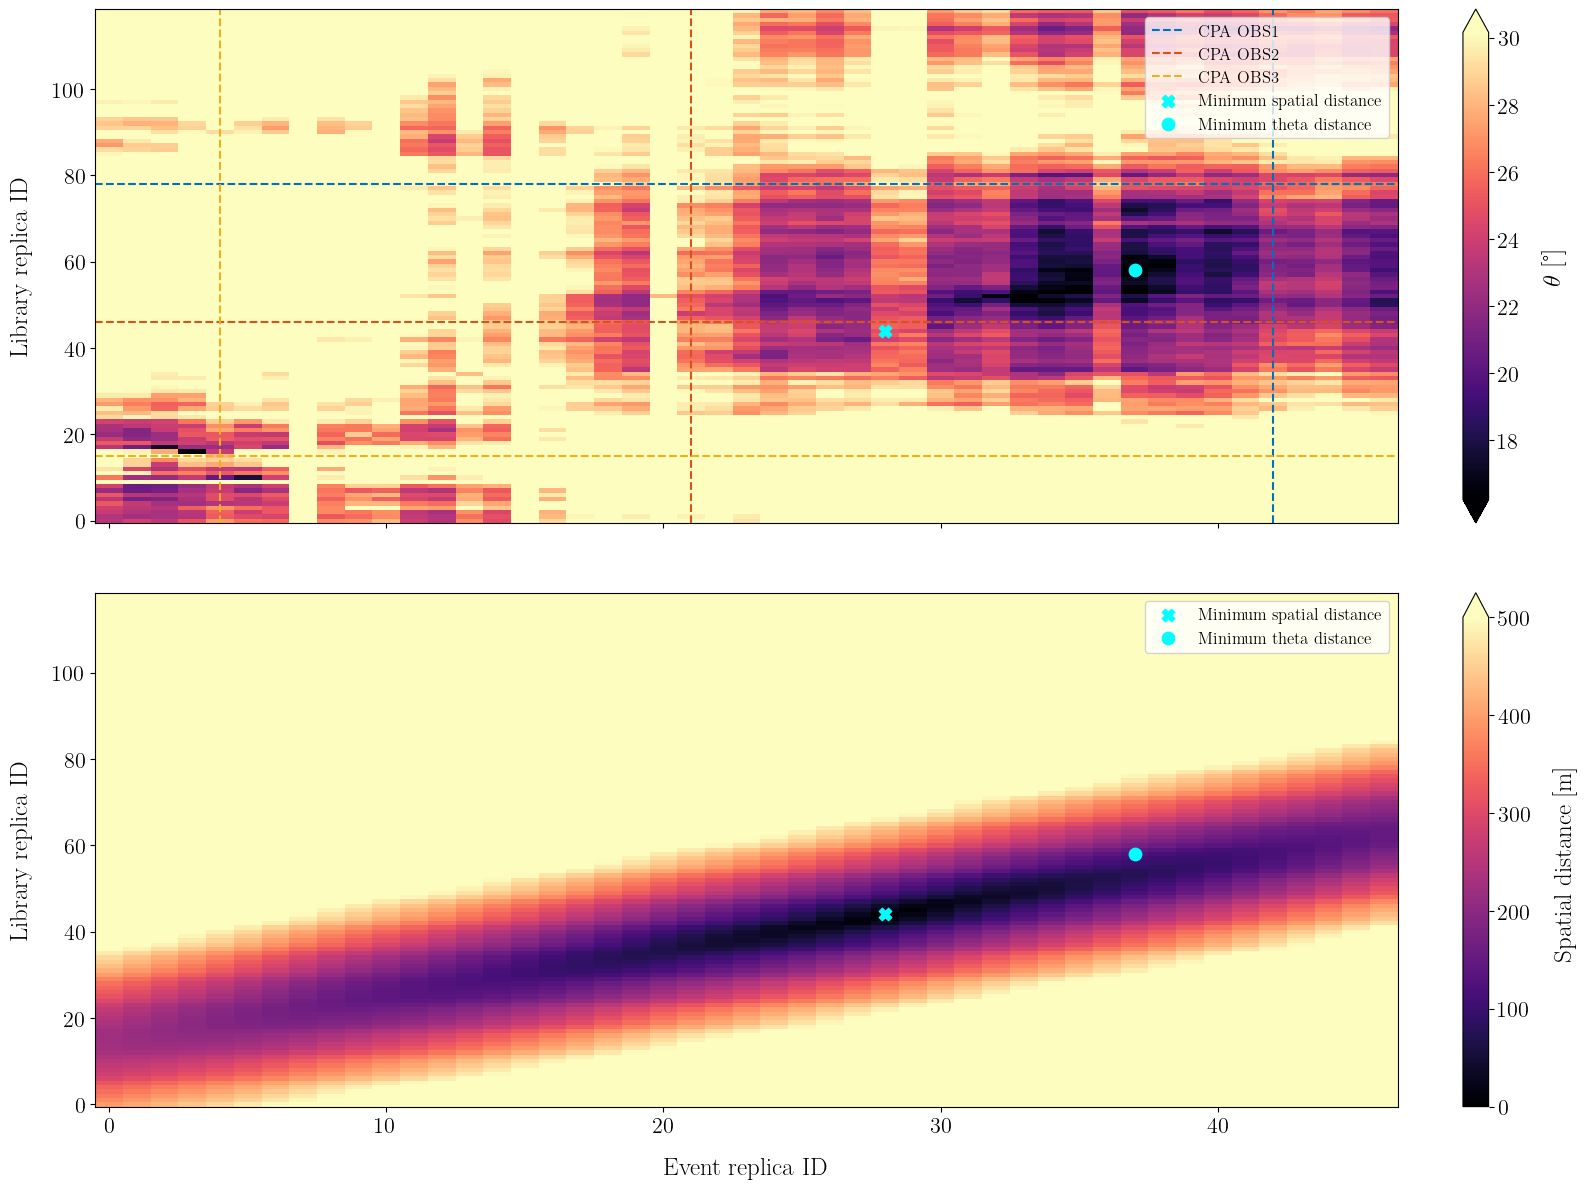

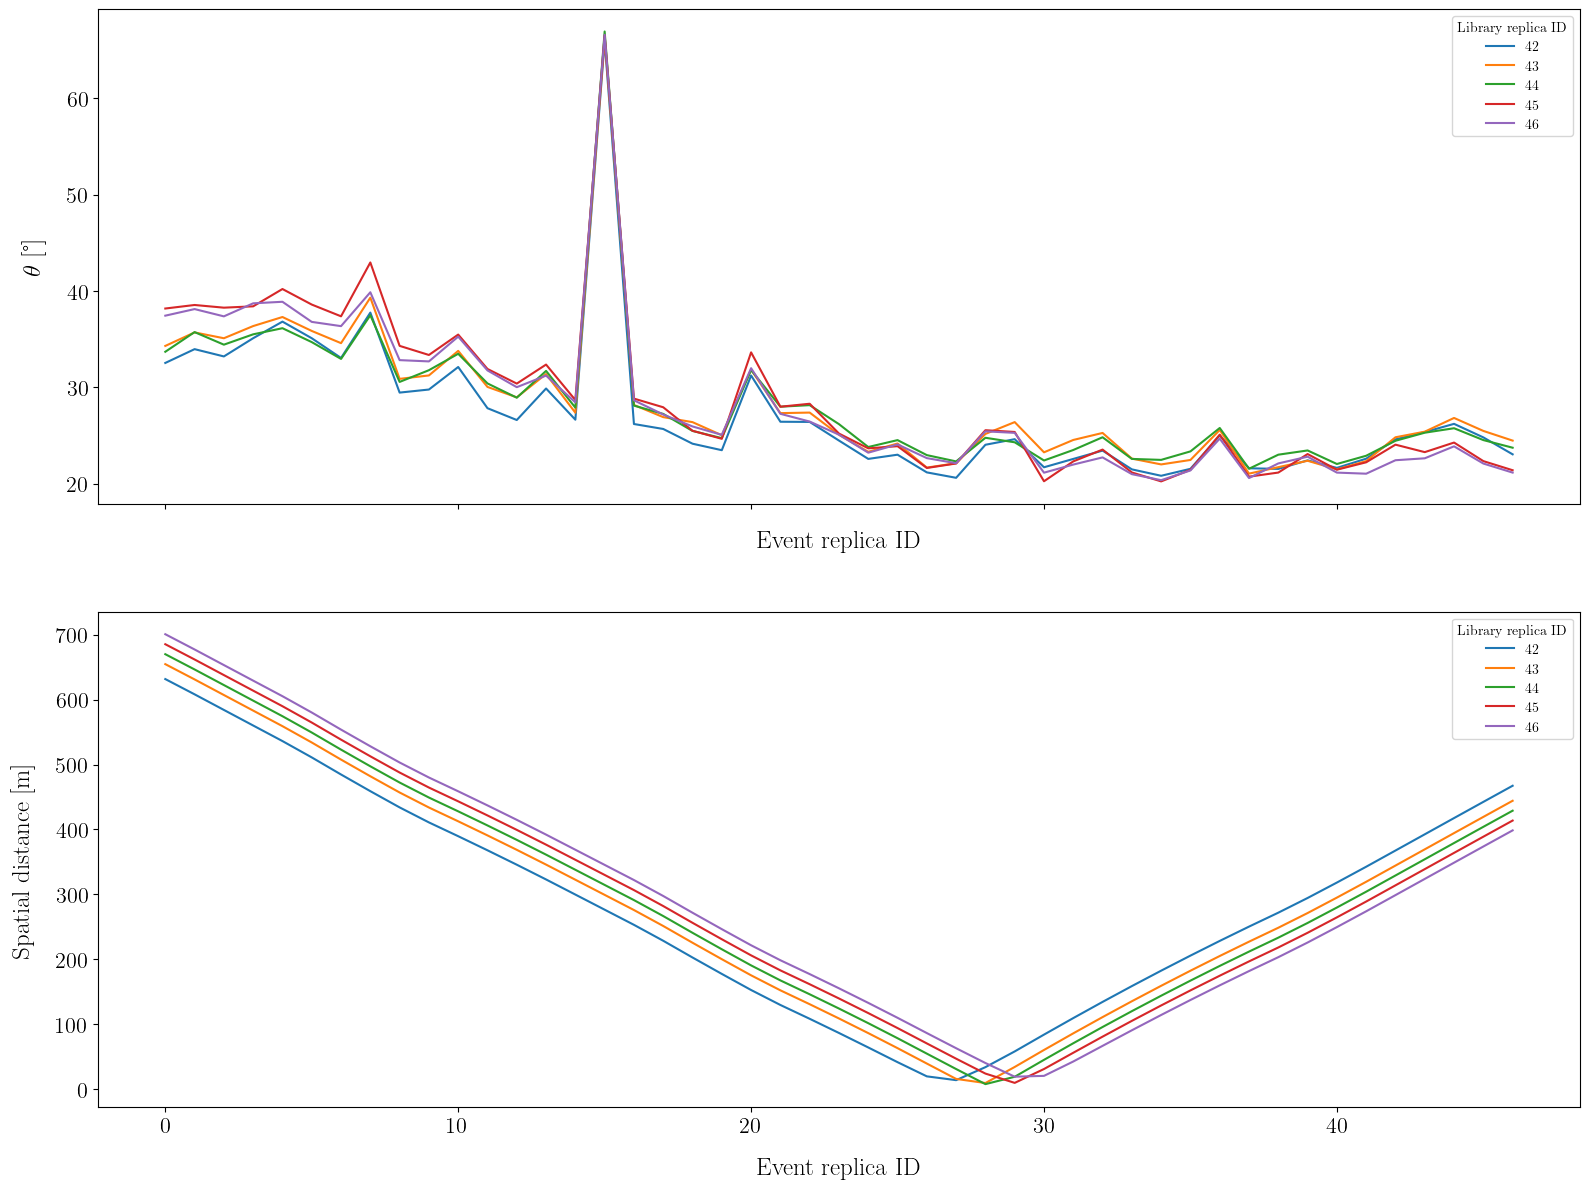

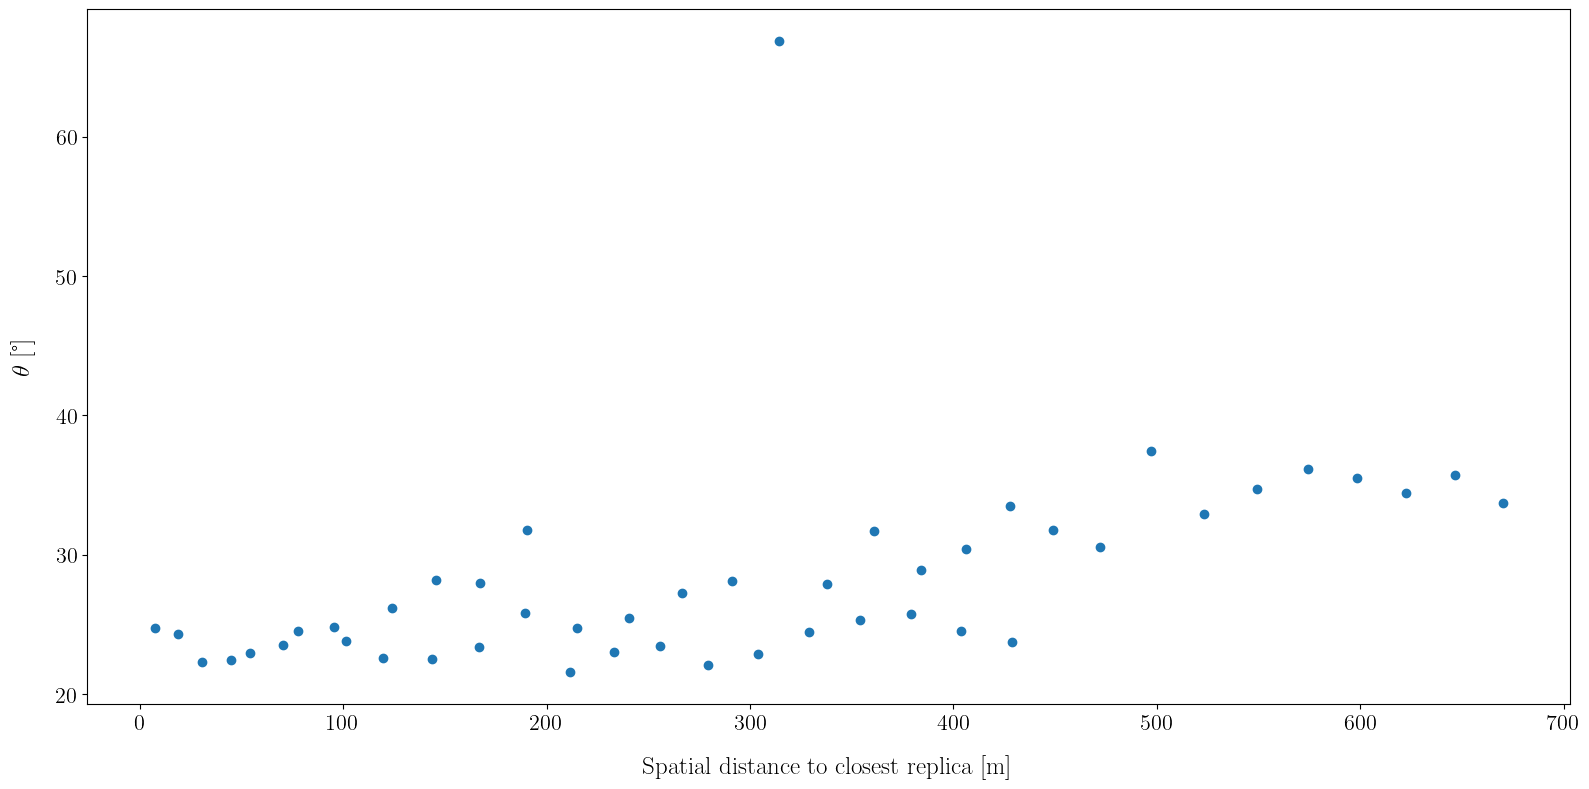

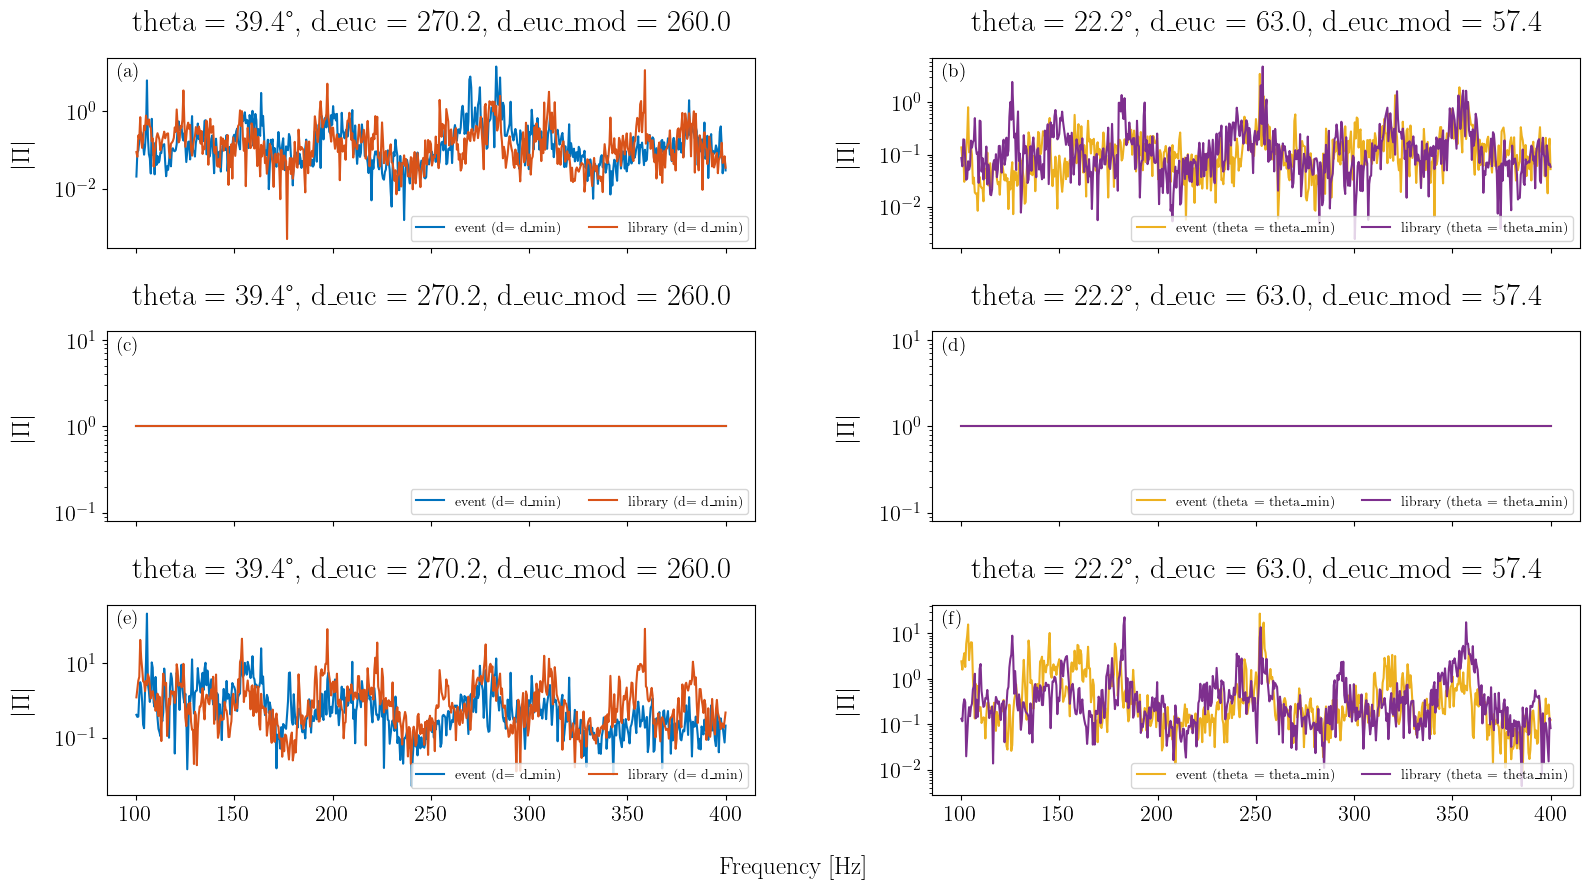

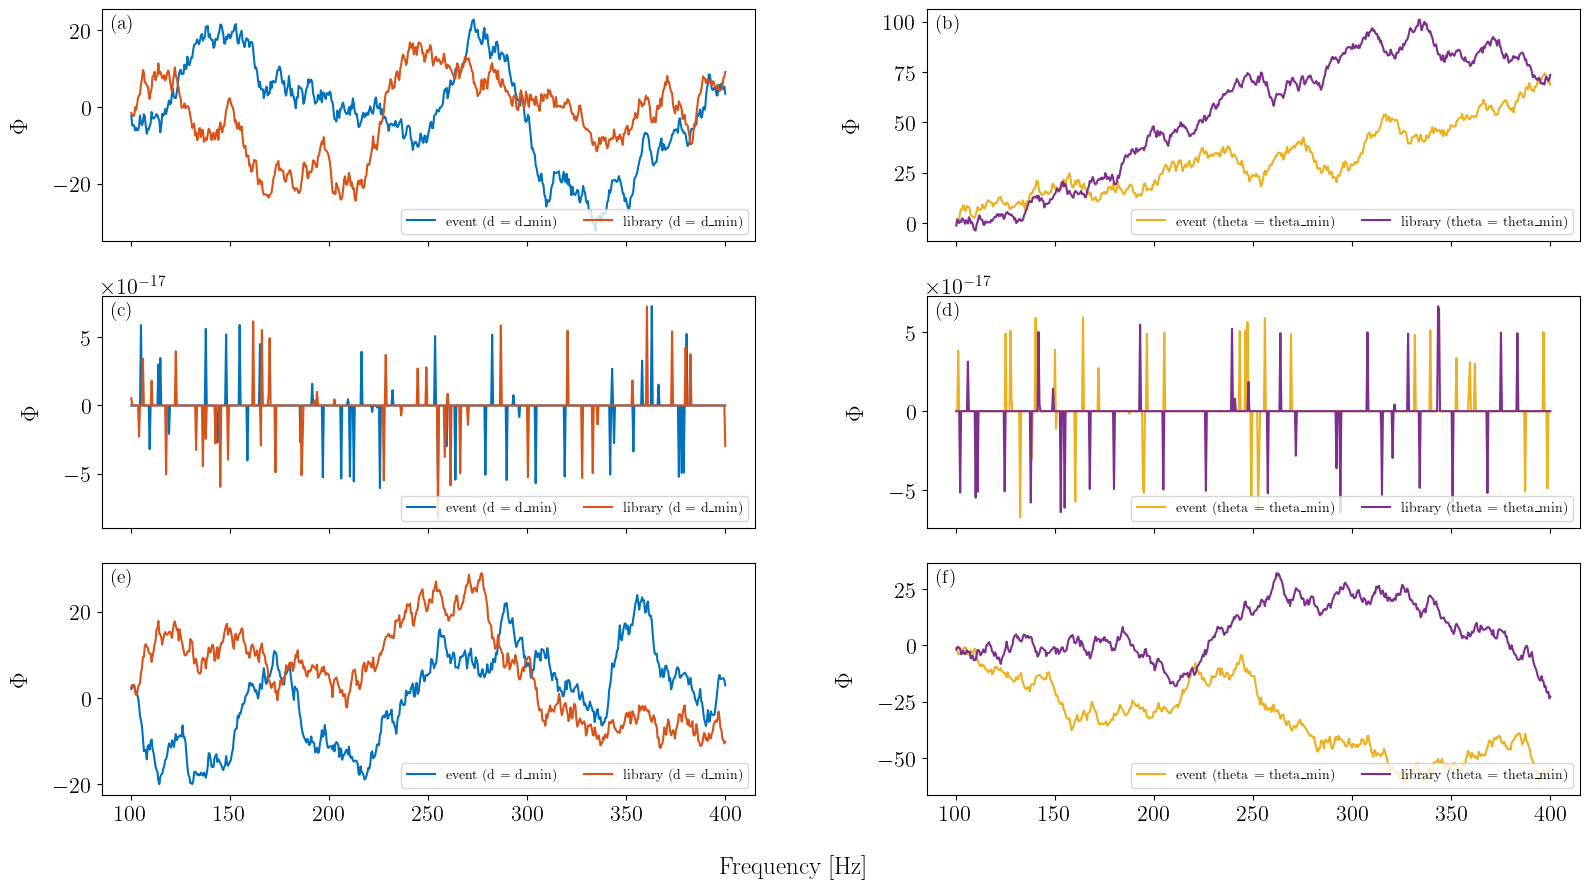

In [17]:
###########################
# Library computation
###########################
id_event = 5
id_library = 5

active_replicas_args = {
    "replica_sequence_ids": [],
    "replica_pulse_slice": [],
    "load_precomputed_feature": True,
}

passive_replicas_args = {
    "start_datetimes": [
        datetime(year=2025, month=10, day=14, hour=1, minute=40, second=00),  # OK lib 2, 3, 4,5
        # datetime(year=2025, month=10, day=15, hour=00, minute=12, second=00),  # OK
    ],
    "end_datetimes": [
        datetime(
            year=2025, month=10, day=14, hour=1, minute=50, second=00
        ),  # OK lib 2, 3, 4,5
        # datetime(year=2025, month=10, day=15, hour=00, minute=25, second=00),  # OK
    ],
    "load_precomputed_feature": True,
}

rtf_mfp_processor.compute_library(
    active_feature_args=active_replicas_args,
    passive_feature_args=passive_replicas_args,
    id=id_library,
    # Rv_global=Rv_library,
)

###########################
# Event computation
###########################

# Derive event
active_feature_args = {
    "replica_sequence_ids": [],
    "load_precomputed_feature": True,
}

target_mmsi = None
passive_feature_args = {
    "start_datetimes": [
        # datetime(year=2025, month=10, day=14, hour=16, minute=40, second=00),
        datetime(year=2025, month=10, day=14, hour=16, minute=44, second=00),
        # datetime(year=2025, month=10, day=14, hour=2, minute=10, second=00),  # OK
    ],
    "end_datetimes": [
        # datetime(year=2025, month=10, day=14, hour=16, minute=50, second=00),
        datetime(year=2025, month=10, day=14, hour=16, minute=48, second=00),
        # datetime(year=2025, month=10, day=14, hour=2, minute=20, second=00),  # OK
    ],
    "load_precomputed_feature": True,
}

rtf_mfp_processor.compute_event(
    active_feature_args=active_feature_args,
    passive_feature_args=passive_feature_args,
    id=id_event,
    target_mmsi=target_mmsi,
    # Rv_global=Rv_event,
)

###########################
# Matching library and event features
###########################

rtf_mfp_processor.match(id_library=id_library, id_event=id_event)

In [18]:
def get_bootstrap_dist(ds, test_replica_id):
    # Select one replica_id to compare using bootstrap
    test_replica = ds.sel(replica_id=test_replica_id)
    # Remove from the rest of the features for bootstraping
    # bootstrap_replica = ds.drop_sel(replica_id=test_replica_id)
    bootstrap_replica = ds

    # Test RTF
    test_replica_rtf = test_replica.rtf_amp * np.exp(1j * test_replica.rtf_phase)

    # Other RTFs
    bootstrap_replica_rtfs = bootstrap_replica.rtf_amp * np.exp(
        1j * bootstrap_replica.rtf_phase
    )

    # Reshape to 4D array to be able to apply distance function : (n_rcv, n_freq, n_segment_dt) -> (n_rcv, n_freq, n_segment_dt, 1)
    bootstrap_replica_rtfs = bootstrap_replica_rtfs.values[..., np.newaxis]

    # Compute dist
    dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_mean": True}
    dist = D_hermitian_angle_fast(
        rtf_ref=test_replica_rtf.values,
        rtf=bootstrap_replica_rtfs,
        **dist_kwargs,
    )

    # # EUCLIDEAN distance
    # d_rcv_1 = np.linalg.norm(
    #     np.abs(test_replica_rtf.sel(h_index=1).values)[:, np.newaxis]
    #     - np.abs(bootstrap_replica_rtfs[0, ...]), axis=0
    # )
    # d_rcv_2 = np.linalg.norm(
    #     np.abs(test_replica_rtf.sel(h_index=2).values)[:, np.newaxis]
    #     - np.abs(bootstrap_replica_rtfs[1, ...]),
    #     axis=0,
    # )
    # d_rcv_3 = np.linalg.norm(
    #     np.abs(test_replica_rtf.sel(h_index=3).values)[:, np.newaxis]
    #     - np.abs(bootstrap_replica_rtfs[2, ...]),
    #     axis=0,
    # )
    # dist = 1 / 3 * (d_rcv_1 + d_rcv_2 + d_rcv_3)

    # # # Compute dist
    # dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_mean": True}
    # dist = D_euclidian(
    #     rtf_ref=np.abs(test_replica_rtf.isel(h_index=slice(0, 1)).values),
    #     rtf=np.abs(bootstrap_replica_rtfs[0:1, ...]),
    #     **dist_kwargs,
    # )

    # # Expand rtf_ref along the necessary axes for broadcasting
    # rtf_ref_expanded = cast_matrix_to_target_shape(rtf_ref, rtf.shape)

    # # Calculate euclidian distance
    # # d_euc = np.sqrt(np.sum(np.abs(rtf_ref_expanded - rtf) ** 2, axis=1))
    # dist = np.linalg.norm(rtf_ref_expanded - rtf, axis=1)

    return dist 

In [19]:
def get_bootstrap_dist_matrix(ds):
    dist_mat = []
    for i, id in enumerate(ds.replica_id.values): 
        dist_id = get_bootstrap_dist(ds=ds, test_replica_id=id)
        # dist_id = np.concatenate([dist_id[0:i], np.array([0]), dist_id[i:]])       # Add 0 on diagonal 
        dist_mat.append(dist_id)

    dist_mat = np.array(dist_mat)
    return dist_mat

In [20]:
# id_event = 0
# id_library = 0
root_img = os.path.join(
    rtf_mfp_processor.root_results_fig, f"library_{id_library}_event_{id_event}"
)

In [21]:
# Load event dataset
ds_event = xr.open_dataset(
    os.path.join(rtf_mfp_processor.root_event_data, f"event_{id_event}.nc")
)

# Select frequency band
fmin = 100
fmax = 400
ds_event = ds_event.sel(f_rtf=slice(fmin, fmax))

theta_mat = get_bootstrap_dist_matrix(ds=ds_event)

In [22]:
def get_dist_to_rcv(ds):
    e = ds["e_replica"].values
    n = ds["n_replica"].values

    rep_pos = np.column_stack((e, n))
    dist_to_rcv = []
    for i_rcv in ds.h_index.values:
        e_rcv = ds.attrs[f"obs{i_rcv}_e_apriori"]
        n_rcv = ds.attrs[f"obs{i_rcv}_n_apriori"]
        rcv_pos = np.column_stack((e_rcv, n_rcv))

        spatial_dist = cdist(rep_pos, rcv_pos, metric="euclidean")
        dist_to_rcv.append(spatial_dist)

    return np.array(dist_to_rcv)


In [23]:
dist_rcv = get_dist_to_rcv(ds=ds_event)

Text(0.5, 0, 'Replica index')

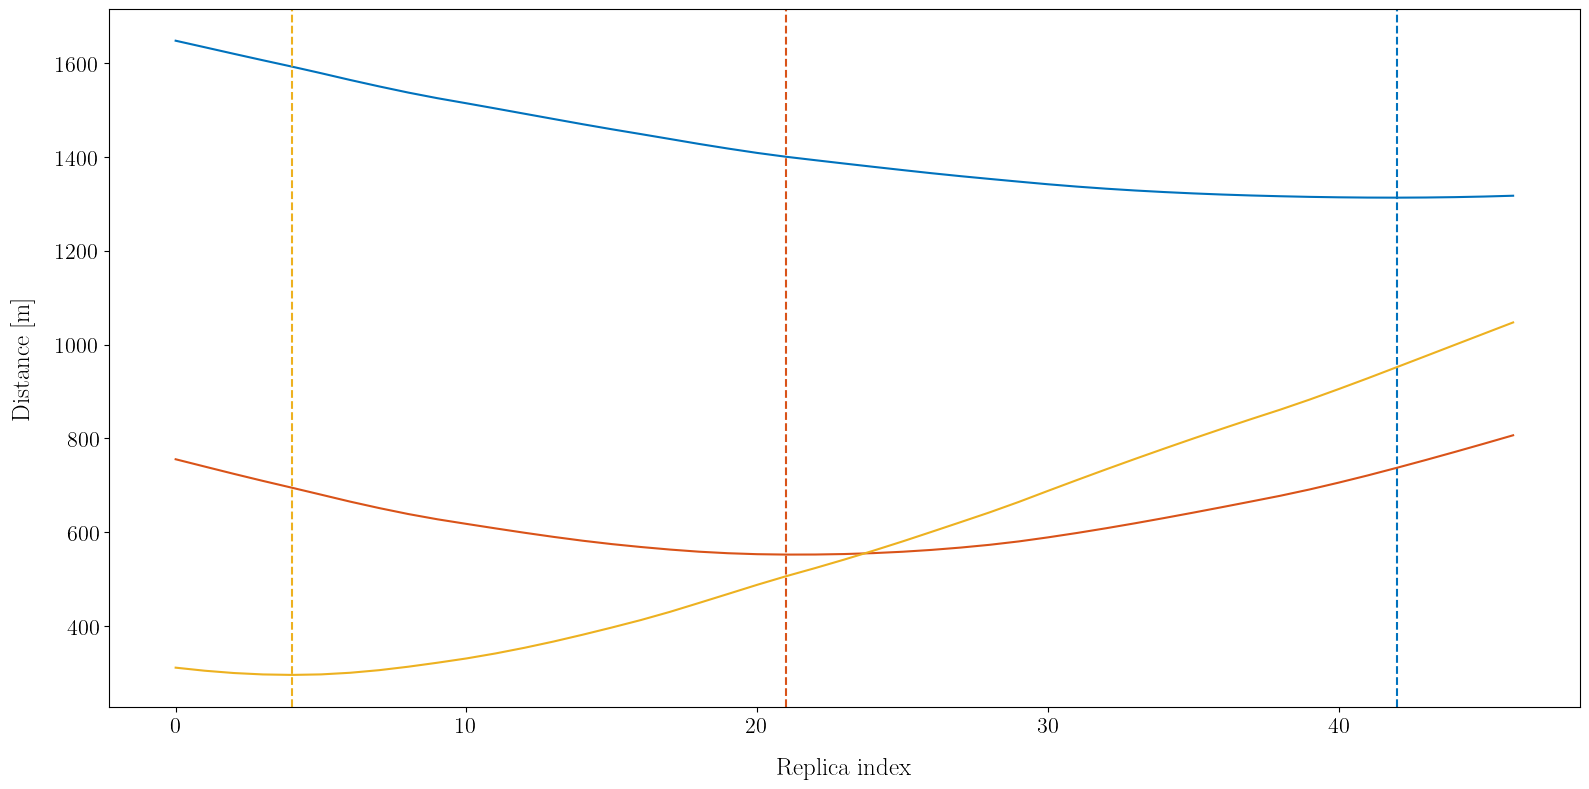

In [24]:
plt.figure()
cpa_idx = []
for i, i_rcv in enumerate(ds_event.h_index.values):
    plt.plot(dist_rcv[i, :], label=f"OBS{i_rcv}", color=color(i))

    cpa_rcv_idx = np.argmin(dist_rcv[i, :])
    plt.axvline(cpa_rcv_idx, linestyle="--", color=color(i))
    cpa_idx.append(cpa_rcv_idx)
    
plt.ylabel(f"Distance [m]")
plt.xlabel("Replica index")

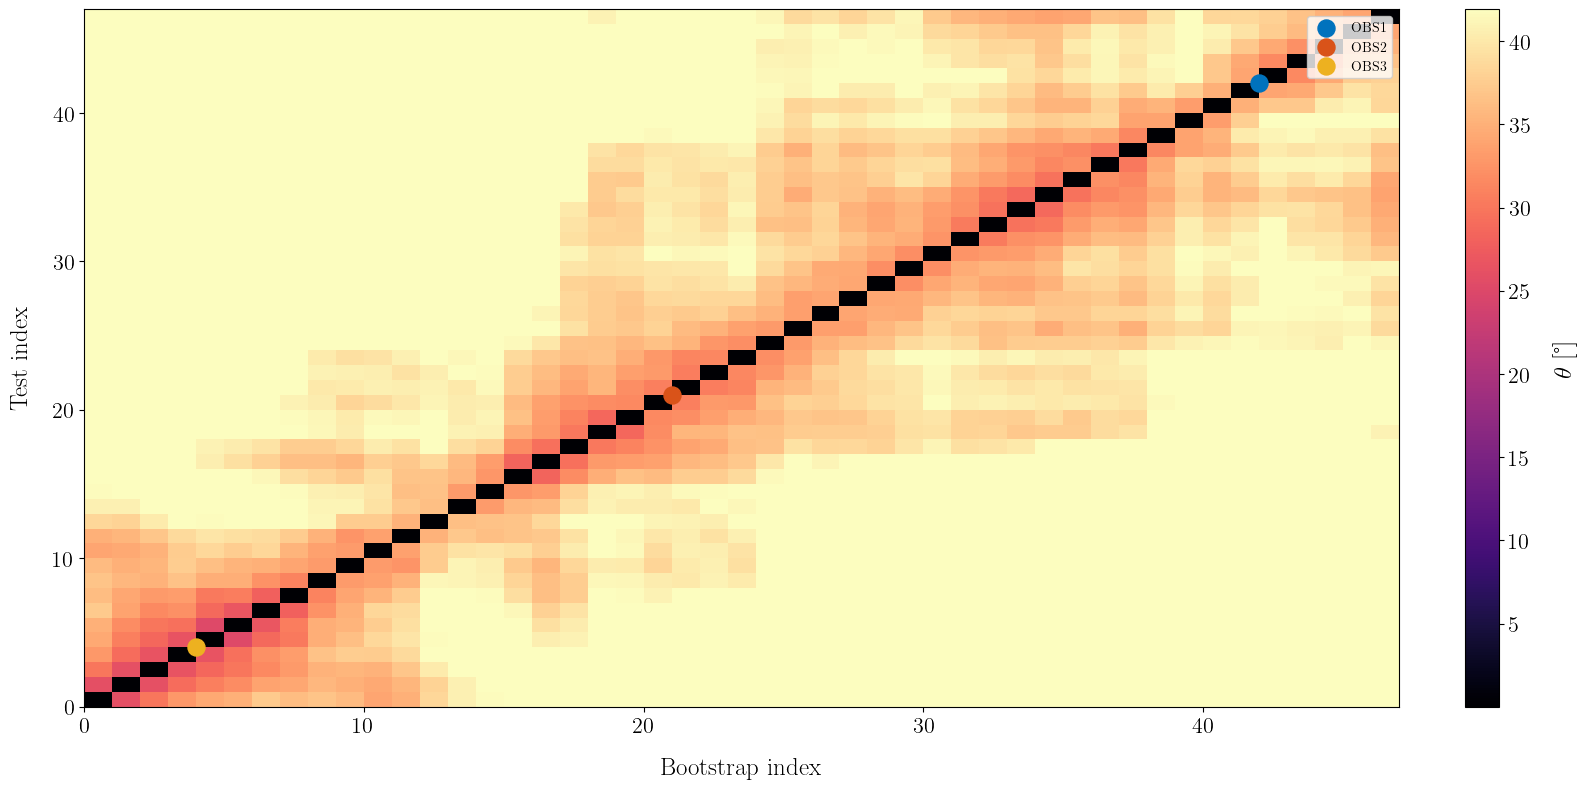

In [25]:
vmax = np.nanpercentile(theta_mat, 50)

plt.figure()
im = plt.pcolormesh(theta_mat, cmap="magma", vmax=vmax)
plt.colorbar(im, label=r"$\theta$ [°]")

# Add CPA indication
for i, i_rcv in enumerate(ds_event.h_index.values):
    plt.scatter(
        cpa_idx[i], cpa_idx[i], marker="o", s=150, color=color(i), label=f"OBS{i_rcv}"
    )
plt.xlabel("Bootstrap index")
plt.ylabel("Test index")
plt.legend()

fpath = os.path.join(
    root_img,
    f"bootstrap_event_win{rtf_mfp_processor.fsm_passive_analysis_segment_duration}s_overlap{rtf_mfp_processor.fsm_passive_analysis_segment_alpha_overlap}.png",
)
plt.savefig(fpath)

In [26]:
# Same test with library
ds_library = xr.open_dataset(
    os.path.join(rtf_mfp_processor.root_library_data, f"library_{id_library}.nc")
)
# Select frequency band
fmin = 100
fmax = 400
ds_library = ds_library.sel(f_rtf=slice(fmin, fmax))

theta_mat_lib = get_bootstrap_dist_matrix(ds=ds_library)

In [27]:
dist_rcv = get_dist_to_rcv(ds=ds_library)

Text(0.5, 0, 'Replica index')

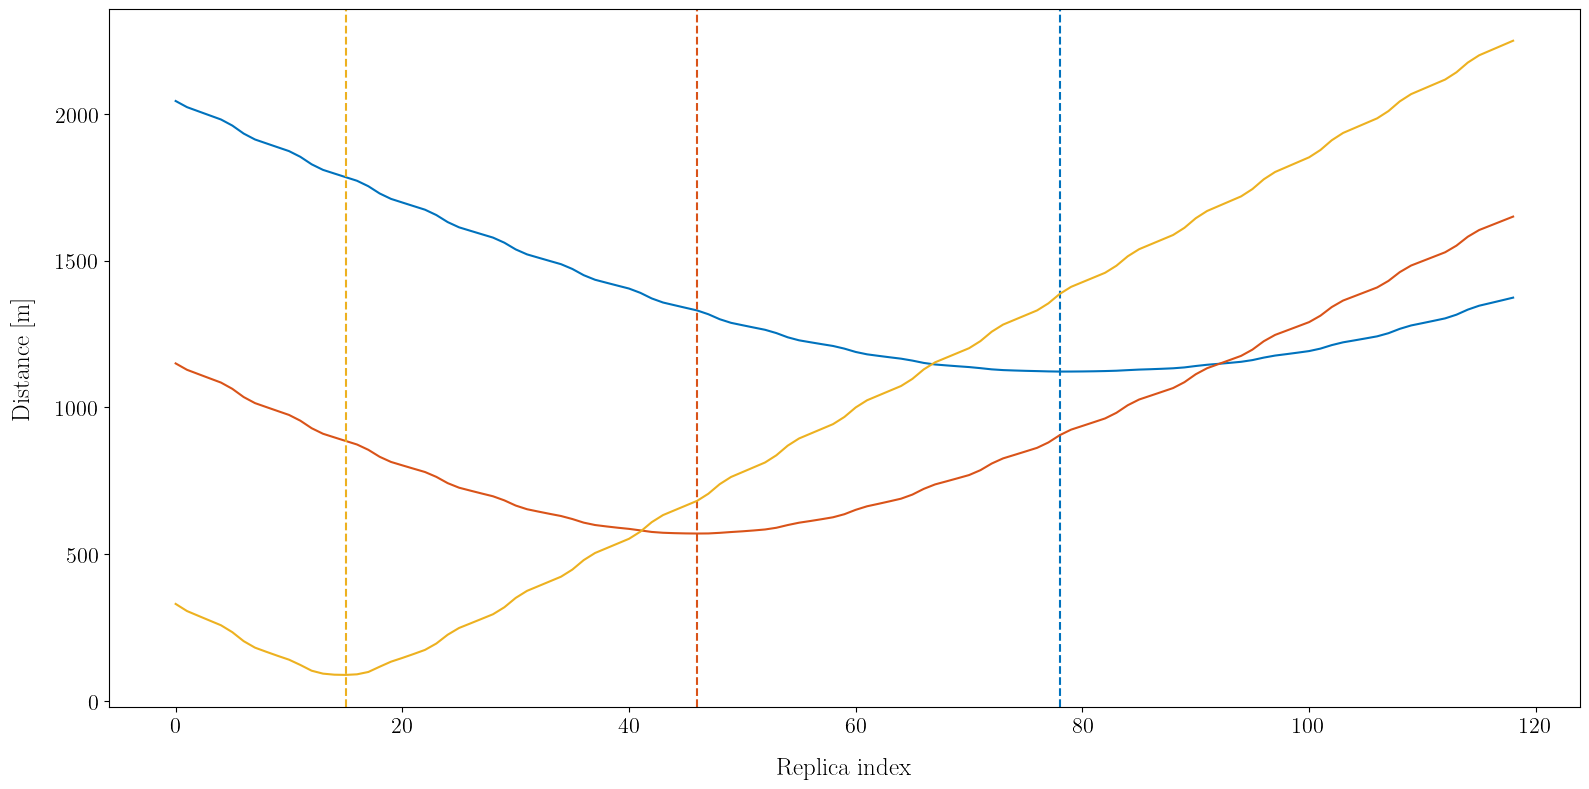

In [28]:
plt.figure()
cpa_idx = []
for i, i_rcv in enumerate(ds_library.h_index.values):
    plt.plot(dist_rcv[i, :], label=f"OBS{i_rcv}", color=color(i))

    cpa_rcv_idx = np.argmin(dist_rcv[i, :])
    plt.axvline(cpa_rcv_idx, linestyle="--", color=color(i))
    cpa_idx.append(cpa_rcv_idx)
    
plt.ylabel(f"Distance [m]")
plt.xlabel("Replica index")

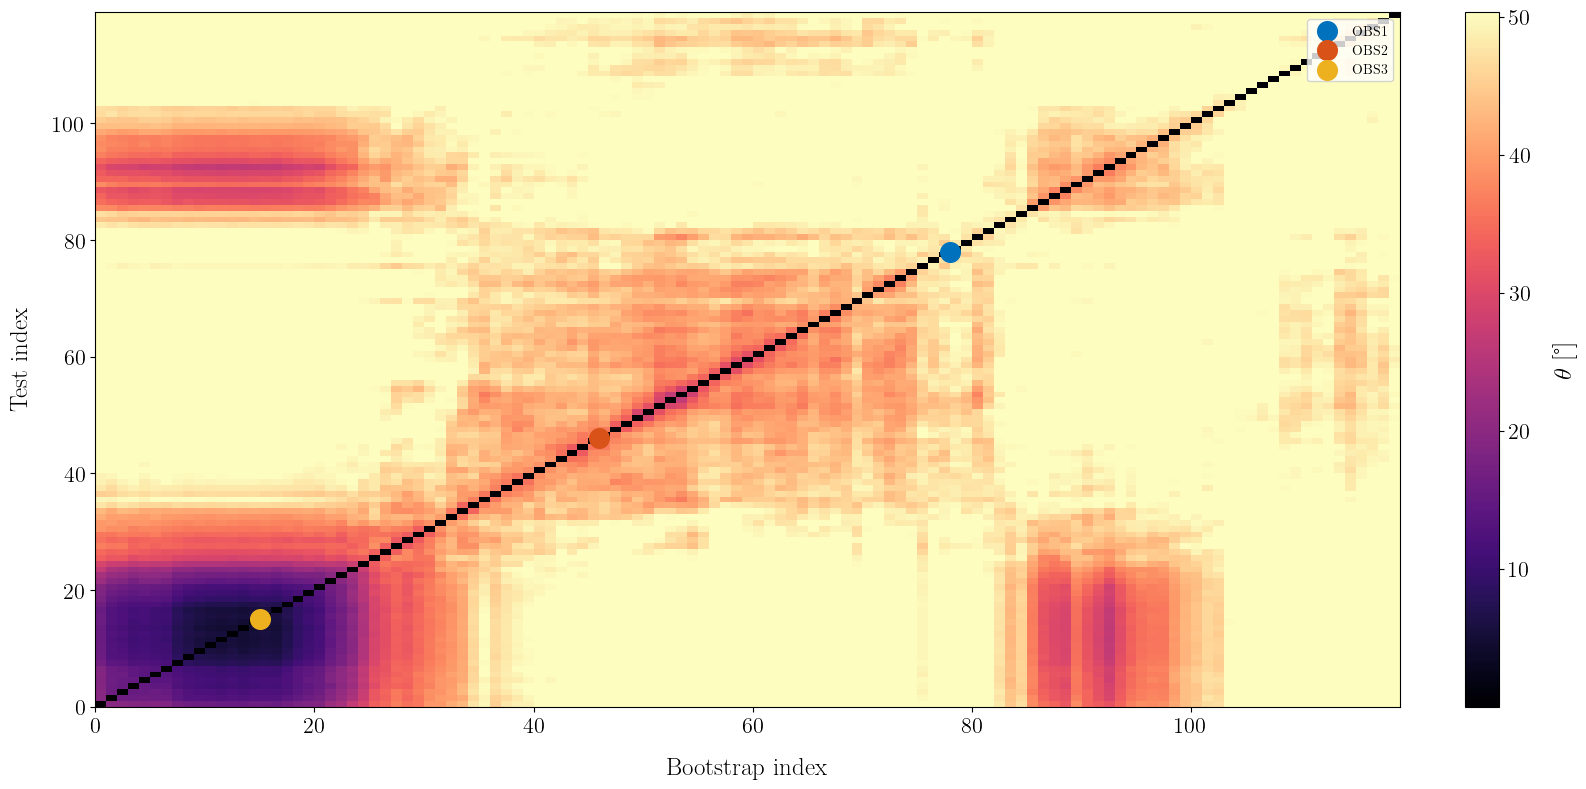

In [29]:
vmax = np.nanpercentile(theta_mat_lib, 50)

plt.figure()
im = plt.pcolormesh(theta_mat_lib, cmap="magma", vmax=vmax)
plt.colorbar(im, label=r"$\theta$ [°]")
# Add CPA indication
for i, i_rcv in enumerate(ds_event.h_index.values):
    plt.scatter(
        cpa_idx[i], cpa_idx[i], marker="o", s=200, color=color(i), label=f"OBS{i_rcv}"
    )
plt.xlabel("Bootstrap index")
plt.ylabel("Test index")
plt.legend()

fpath = os.path.join(
    root_img,
    f"bootstrap_lib_win{rtf_mfp_processor.fsm_passive_analysis_segment_duration}s_overlap{rtf_mfp_processor.fsm_passive_analysis_segment_alpha_overlap}.png",
)
plt.savefig(fpath)

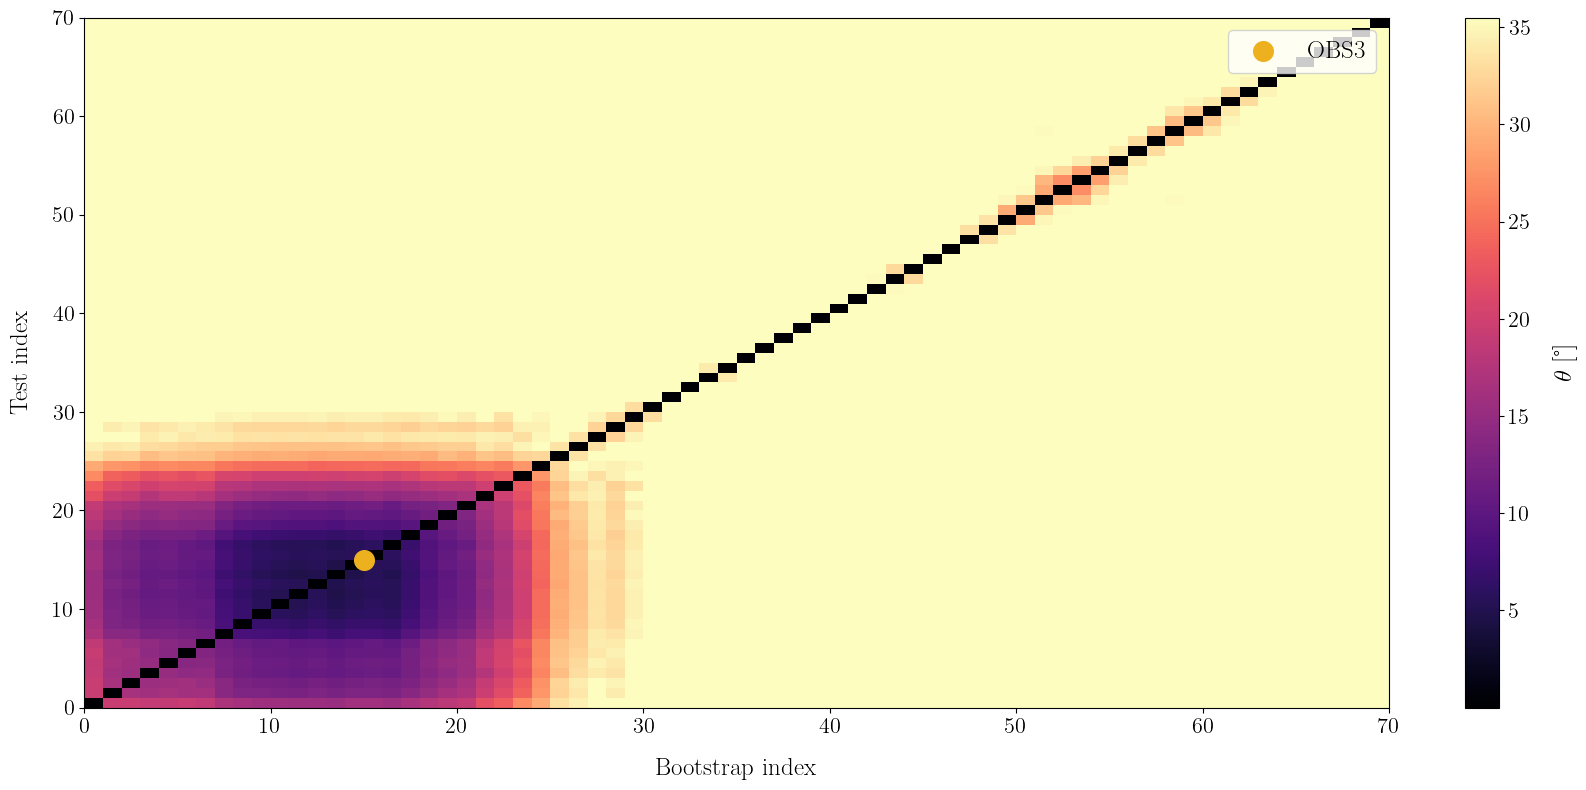

In [30]:
# zoom sur la zone du CPA de l'obs 3

vmax = np.nanpercentile(theta_mat_lib, 10)

idx_min = 0
idx_max = 70
plt.figure()
im = plt.pcolormesh(
    theta_mat_lib[idx_min:idx_max, idx_min:idx_max], cmap="magma", vmax=vmax
)

plt.colorbar(im, label=r"$\theta$ [°]")
# Add CPA indication
plt.scatter(cpa_idx[2], cpa_idx[2], marker="o", s=200, color=color(2), label=f"OBS{3}")
plt.xlabel("Bootstrap index")
plt.ylabel("Test index")
plt.legend(fontsize=18)

fpath = os.path.join(
    root_img,
    f"bootstrap_lib_win{rtf_mfp_processor.fsm_passive_analysis_segment_duration}s_overlap{rtf_mfp_processor.fsm_passive_analysis_segment_alpha_overlap}_zoomobs3.png",
)
plt.savefig(fpath)

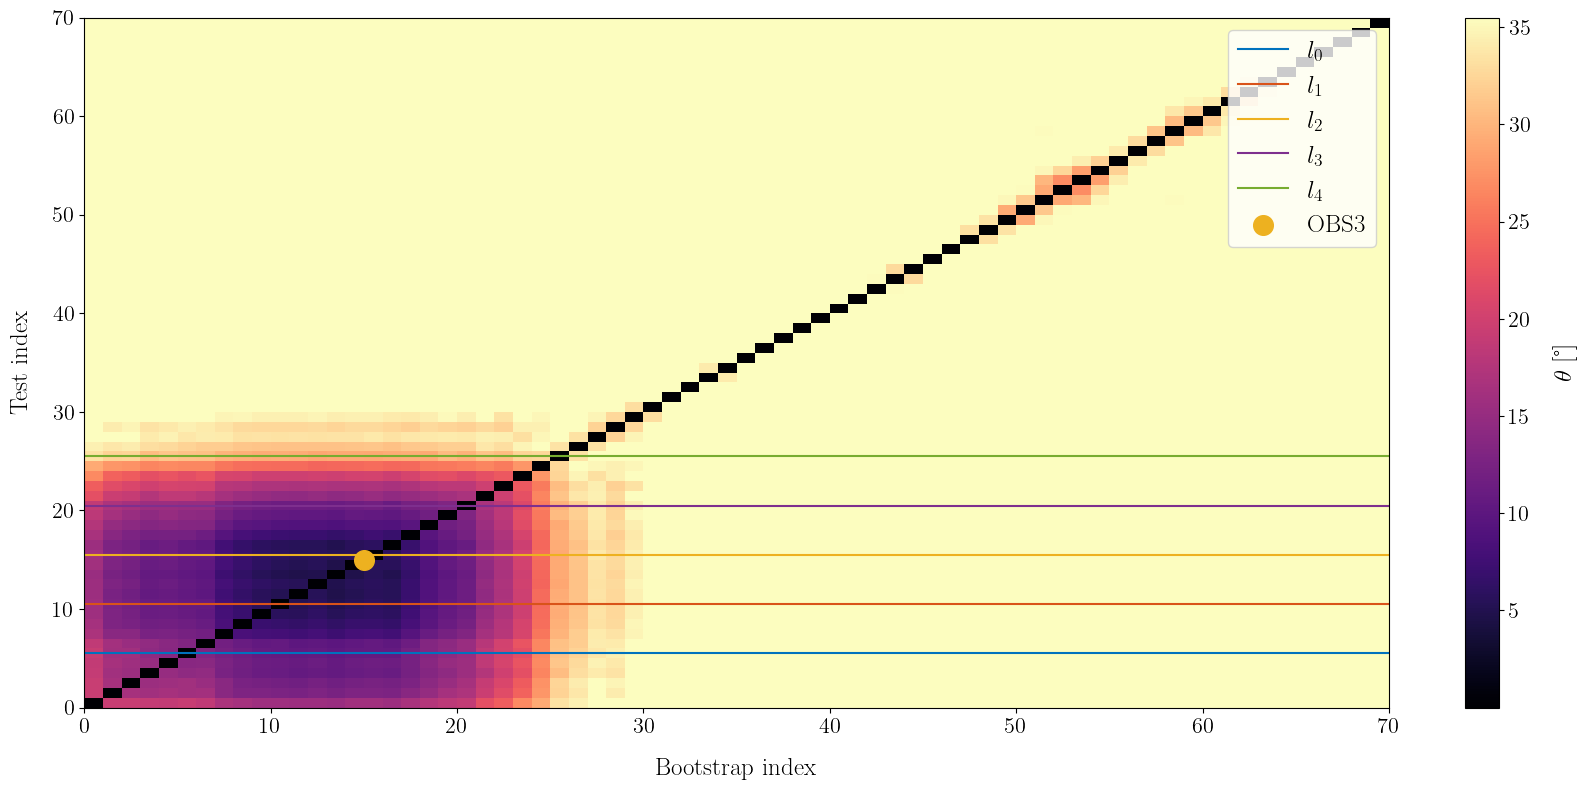

In [31]:
# Quelques lignes à la loupe
i_1 = 5
i_2 = 10
i_3 = 15
i_4 = 20
i_5 = 25
i_ls = [i_1, i_2, i_3, i_4, i_5]

plt.figure()
im = plt.pcolormesh(
    theta_mat_lib[idx_min:idx_max, idx_min:idx_max], cmap="magma", vmax=vmax
)
for k, i_l in enumerate(i_ls):
    plt.axhline(i_l+0.5, color=color(k), label=rf"$l_{k}$")

plt.colorbar(im, label=r"$\theta$ [°]")
# Add CPA indication
plt.scatter(
    cpa_idx[2], cpa_idx[2], marker="o", s=200, color=color(2), label=f"OBS{3}"
)
plt.xlabel("Bootstrap index")
plt.ylabel("Test index")
plt.legend(fontsize=18)

fpath = os.path.join(
    root_img,
    f"bootstrap_lib_win{rtf_mfp_processor.fsm_passive_analysis_segment_duration}s_overlap{rtf_mfp_processor.fsm_passive_analysis_segment_alpha_overlap}_zoomobs3_lines.png",
)
plt.savefig(fpath)

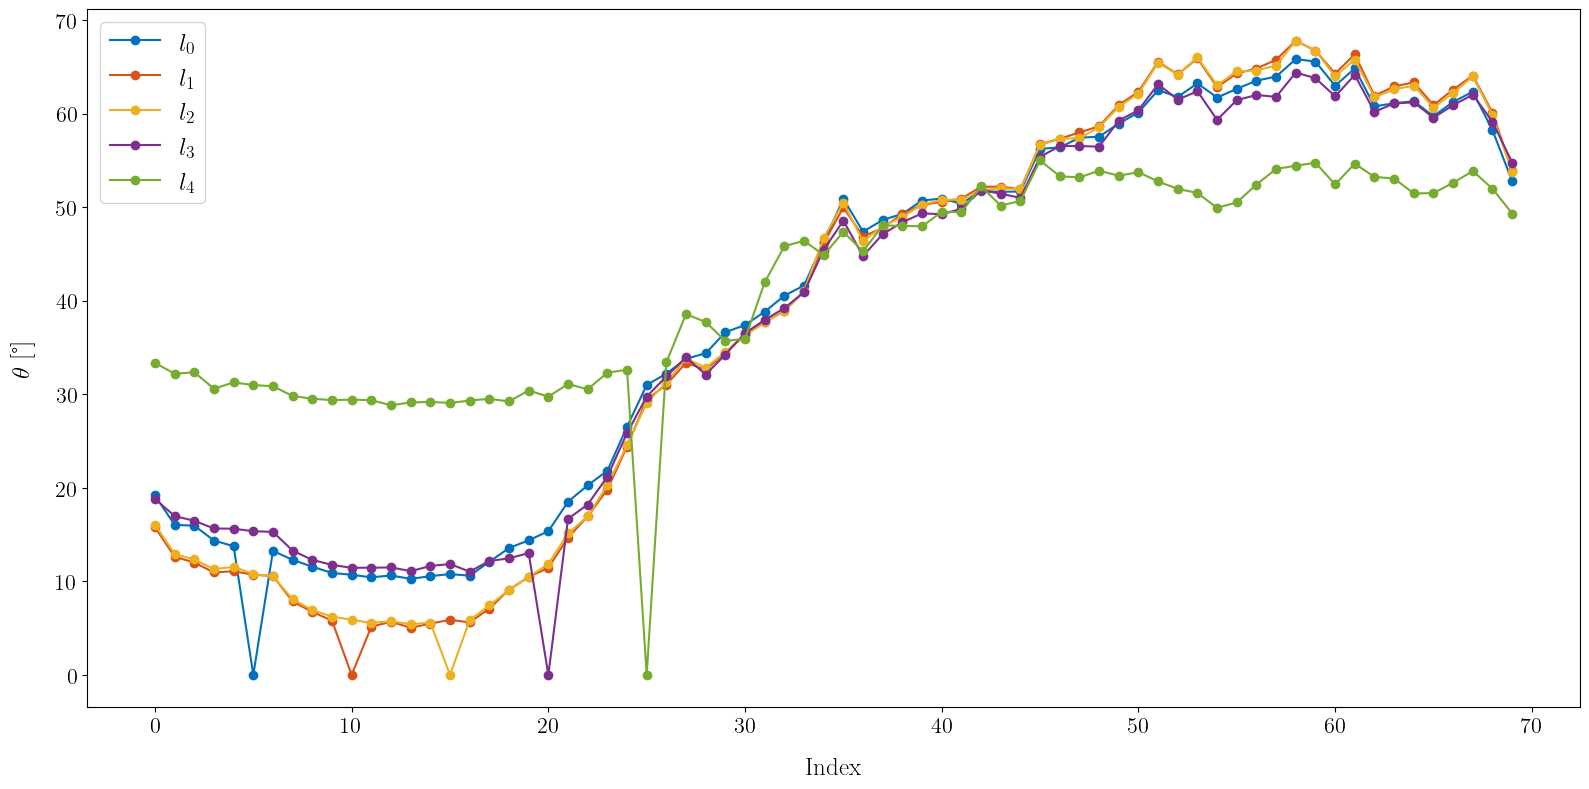

In [32]:
plt.figure()
for k, i_l in enumerate(i_ls):
    plt.plot(theta_mat_lib[i_l, idx_min:idx_max], marker="o", color=color(k), label=rf"$l_{k}$")

plt.legend(fontsize=18)
plt.xlabel("Index")
plt.ylabel(r"$\theta$ [°]")

fpath = os.path.join(
    root_img,
    f"bootstrap_lib_win{rtf_mfp_processor.fsm_passive_analysis_segment_duration}s_overlap{rtf_mfp_processor.fsm_passive_analysis_segment_alpha_overlap}_zoomobs3_asymetry.png",
)
plt.savefig(fpath)

In [33]:

# h_plot = 3

# ### Compare two adjacent features ###
# rtf_1_mod = min_dist_event.rtf_amp.sel(h_index=h_plot).sel(f_rtf=slice(fmin, fmax))
# rtf_2_mod = min_dist_p1_event.rtf_amp.sel(h_index=h_plot).sel(
#     f_rtf=slice(fmin, fmax)
# )
# rtf_1_phase = min_dist_event.rtf_phase.sel(h_index=h_plot).sel(
#     f_rtf=slice(fmin, fmax)
# )
# # rtf_2_phase = min_dist_p1_event.rtf_phase.sel(h_index=h_plot).sel(
# #     f_rtf=slice(fmin, fmax)
# # )
# rtf_2_phase = rtf_1_phase

# rtf_1 = rtf_1_mod * np.exp(1j * rtf_1_phase)
# rtf_2 = rtf_2_mod * np.exp(1j * rtf_2_phase)

# euc_dist = np.linalg.norm(rtf_1 - rtf_2)
# euc_mod_dist = np.linalg.norm(rtf_1_mod - rtf_2_mod)
# dist_kwargs = {"ax_rcv": 1, "ax_f": 0, "apply_mean": False, "unit": "deg"}
# theta_along_f = D_hermitian_angle_fast(
#     rtf_ref=np.atleast_2d(rtf_1),
#     rtf=np.atleast_2d(rtf_2),
#     **dist_kwargs,
# )
# # Classical hermitian angle
# rtf_1_mod = min_dist_event.rtf_amp.sel(f_rtf=slice(fmin, fmax))
# rtf_2_mod = min_dist_p1_event.rtf_amp.sel(f_rtf=slice(fmin, fmax))
# rtf_1_phase = min_dist_event.rtf_phase.sel(f_rtf=slice(fmin, fmax))
# rtf_2_phase = min_dist_p1_event.rtf_phase.sel(f_rtf=slice(fmin, fmax))
# rtf_1 = rtf_1_mod * np.exp(1j * rtf_1_phase)
# rtf_2 = rtf_2_mod * np.exp(1j * rtf_2_phase)

# euc_dist = np.linalg.norm(rtf_1 - rtf_2)
# euc_mod_dist = np.linalg.norm(rtf_1_mod - rtf_2_mod)
# dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_mean": True}
# theta_along_rcv = D_hermitian_angle_fast(
#     rtf_ref=rtf_1.values,
#     rtf=rtf_2.values,
#     **dist_kwargs,
# )

# print(f"Euclidian distance (module) at d = d_min = {euc_mod_dist}")
# print(f"Euclidian distance (in C) at d = d_min = {euc_dist}")
# print(f"Hermitian angle distance along freq (in C) at d = d_min = {theta_along_f}°")
# print(
#     f"Hermitian angle distance along rcv (in C^n_rcv) at d = d_min = {theta_along_rcv}°"
# )